# 07 — Group-Aware Robustness, Calibration, and Responsible Evaluation

## M7A — Objective and Evaluation Boundary

This notebook evaluates the robustness of the preferred development-stage histogram gradient-boosting model selected in Notebook 06.

The objective is not to perform additional model-family search or hyperparameter tuning. Instead, the analysis focuses on:

- patient-group-aware cross-validation,
- out-of-fold discrimination,
- uncertainty estimation,
- calibration,
- nested screening-threshold evaluation, and
- subgroup performance auditing.

### Evaluation Boundary

The original held-out test partition was already observed during Notebook 06 when evaluating the optimized random forest. Histogram gradient boosting was subsequently selected using development-stage validation evidence.

Accordingly, this notebook does **not** reuse the original held-out test partition.

Only the original training and validation partitions are combined into the development pool for group-aware robustness analysis.

The held-out test file is not loaded, transformed, scored, or used for threshold selection anywhere in this notebook.

### Locked Model Family

The preferred development model from Notebook 06 is retained without additional hyperparameter search:

- `HistGradientBoostingClassifier`
- `learning_rate = 0.03`
- `max_iter = 400`
- `max_leaf_nodes = 31`
- `min_samples_leaf = 40`
- `l2_regularization = 2.0`

All cross-validation folds will train a fresh HGB model using these fixed hyperparameters.

### Patient-Level Independence

Because some patients have multiple encounters, validation folds must be separated by `patient_nbr`.

No patient's encounters may appear in both the training and evaluation portion of the same fold.

Preprocessing rules that are learned from data must also be fitted within each training fold to avoid information leakage.

### Interpretation of Results

Results from this notebook provide post-selection robustness evidence for the locked HGB development model.

They do not constitute a new independent external test estimate. A future untouched dataset or external cohort would still be required for independent confirmation of generalization performance.

In [1]:
# M7A — Imports and project paths

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
)

warnings.filterwarnings("ignore")

# -------------------------------------------------------------------
# Project paths
# -------------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

TRAIN_PATH = PROCESSED_DIR / "train.csv"
VALIDATION_PATH = PROCESSED_DIR / "validation.csv"

# The held-out test path is defined only for an explicit safety audit.
# It must never be read in Notebook 07.
TEST_PATH = PROCESSED_DIR / "test.csv"

FEATURE_REGISTRY_PATH = PROCESSED_DIR / "feature_registry.json"

CATEGORY_REGISTRY_PATH = REPORTS_DIR / "category_registry.json"

PREPROCESSOR_METADATA_PATH = REPORTS_DIR / "baseline_preprocessor_metadata.json"

TRANSFORMED_FEATURE_NAMES_PATH = REPORTS_DIR / "baseline_transformed_feature_names.json"

print("NOTEBOOK 07 SETUP")
print("=" * 82)

print(f"Project root:       {PROJECT_ROOT}")
print(f"Training data:      {TRAIN_PATH}")
print(f"Validation data:    {VALIDATION_PATH}")
print(f"Held-out test path: {TEST_PATH}")

print("\nEvaluation boundary:")
print("✓ Train and validation partitions may be used.")
print("✓ Held-out test partition must not be loaded.")
print("✓ HGB hyperparameters are frozen from Notebook 06.")
print("✓ Patient-aware grouping will be enforced.")

NOTEBOOK 07 SETUP
Project root:       c:\Users\amohe.000\Downloads\healthcare-readmission-analytics
Training data:      c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\data\processed\train.csv
Validation data:    c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\data\processed\validation.csv
Held-out test path: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\data\processed\test.csv

Evaluation boundary:
✓ Train and validation partitions may be used.
✓ Held-out test partition must not be loaded.
✓ HGB hyperparameters are frozen from Notebook 06.
✓ Patient-aware grouping will be enforced.


In [2]:
# Explicit Notebook 07 test-isolation audit

assert TRAIN_PATH.exists()
assert VALIDATION_PATH.exists()

# It is acceptable for the test file to exist on disk.
# The contract is that Notebook 07 never reads it.
assert TEST_PATH.exists()

HGB_LOCKED_PARAMS = {
    "learning_rate": 0.03,
    "max_iter": 400,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 40,
    "l2_regularization": 2.0,
}

assert HGB_LOCKED_PARAMS == {
    "learning_rate": 0.03,
    "max_iter": 400,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 40,
    "l2_regularization": 2.0,
}

print("NOTEBOOK 07 EVALUATION CONTRACT")
print("=" * 82)

print("Locked HGB hyperparameters:")
for key, value in HGB_LOCKED_PARAMS.items():
    print(f"  {key}: {value}")

print("\n✓ Test file existence confirmed but not loaded.")
print("✓ Model family and hyperparameters locked.")
print("✓ No tuning permitted in Notebook 07.")

NOTEBOOK 07 EVALUATION CONTRACT
Locked HGB hyperparameters:
  learning_rate: 0.03
  max_iter: 400
  max_leaf_nodes: 31
  min_samples_leaf: 40
  l2_regularization: 2.0

✓ Test file existence confirmed but not loaded.
✓ Model family and hyperparameters locked.
✓ No tuning permitted in Notebook 07.


## M7B — Development Data Reconstruction

Notebook 07 uses only the original training and validation partitions.

These partitions are combined into a single development pool for patient-group-aware cross-validation. The original held-out test partition remains isolated and is not read.

Before constructing cross-validation folds, the development pool is audited for:

- row counts,
- target prevalence,
- patient identifiers,
- repeated-patient frequency,
- encounter uniqueness, and
- target consistency.

The `patient_nbr` identifier is retained only for grouping and is never used as a model predictor.

In [3]:
# Load train + validation only

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)

development_df = pd.concat(
    [
        train_df.assign(source_partition="train"),
        validation_df.assign(source_partition="validation"),
    ],
    axis=0,
    ignore_index=True,
)

print("DEVELOPMENT DATA RECONSTRUCTION")
print("=" * 82)

print(f"Training rows:      {len(train_df):,}")
print(f"Validation rows:    {len(validation_df):,}")
print(f"Development rows:   {len(development_df):,}")

print("\nPartition counts:")
print(development_df["source_partition"].value_counts().to_string())

assert len(development_df) == (len(train_df) + len(validation_df))

print("\n✓ Train and validation combined.")
print("✓ Held-out test partition not loaded.")

DEVELOPMENT DATA RECONSTRUCTION
Training rows:      71,520
Validation rows:    15,027
Development rows:   86,547

Partition counts:
source_partition
train         71520
validation    15027

✓ Train and validation combined.
✓ Held-out test partition not loaded.


In [4]:
# Audit development target and patient grouping structure

TARGET_COLUMN = "readmitted_30d"
GROUP_COLUMN = "patient_nbr"
ENCOUNTER_COLUMN = "encounter_id"

required_columns = {
    TARGET_COLUMN,
    GROUP_COLUMN,
    ENCOUNTER_COLUMN,
}

missing_columns = required_columns - set(development_df.columns)

assert not missing_columns, f"Missing required columns: {missing_columns}"

assert development_df[TARGET_COLUMN].isin([0, 1]).all()

assert development_df[GROUP_COLUMN].notna().all()

assert development_df[ENCOUNTER_COLUMN].notna().all()

assert development_df[ENCOUNTER_COLUMN].is_unique

development_rows = len(development_df)

development_patients = development_df[GROUP_COLUMN].nunique()

patient_encounter_counts = development_df.groupby(GROUP_COLUMN).size()

repeated_patients = int((patient_encounter_counts > 1).sum())

repeated_patient_rate = repeated_patients / development_patients

target_prevalence = development_df[TARGET_COLUMN].mean()

print("DEVELOPMENT PATIENT / TARGET AUDIT")
print("=" * 82)

print(f"Development encounters:        " f"{development_rows:,}")
print(f"Unique patients:               " f"{development_patients:,}")
print(f"Patients with >1 encounter:    " f"{repeated_patients:,}")
print(f"Repeated-patient rate:         " f"{repeated_patient_rate:.2%}")
print(f"Maximum encounters / patient:  " f"{patient_encounter_counts.max():,}")
print(f"30-day readmission prevalence: " f"{target_prevalence:.4f}")

print("\nTarget counts:")
print(development_df[TARGET_COLUMN].value_counts().sort_index().to_string())

print("\n✓ Encounter IDs are unique.")
print("✓ Patient IDs are complete.")
print("✓ Binary target integrity confirmed.")
print("✓ Repeated-patient structure quantified.")
print("✓ patient_nbr reserved for grouping only.")
print("✓ Held-out test partition remains untouched.")

DEVELOPMENT PATIENT / TARGET AUDIT
Development encounters:        86,547
Unique patients:               60,790
Patients with >1 encounter:    14,274
Repeated-patient rate:         23.48%
Maximum encounters / patient:  40
30-day readmission prevalence: 0.1118

Target counts:
readmitted_30d
0    76870
1     9677

✓ Encounter IDs are unique.
✓ Patient IDs are complete.
✓ Binary target integrity confirmed.
✓ Repeated-patient structure quantified.
✓ patient_nbr reserved for grouping only.
✓ Held-out test partition remains untouched.


## M7C — Patient-Level Group Audit

Before constructing the new group-aware cross-validation framework, the original train/validation boundary is audited for patient overlap.

Because some patients have multiple encounters, a patient appearing in both partitions would mean that encounter-level splitting allowed information from the same individual to appear on both sides of the development split.

Notebook 07 therefore treats `patient_nbr` as the grouping unit and requires complete patient separation within every cross-validation fold.

A five-fold `StratifiedGroupKFold` design is then inspected before any model fitting. The objectives are:

- zero patient overlap between fold training and evaluation subsets,
- approximate preservation of 30-day readmission prevalence, and
- complete coverage of all development encounters exactly once as out-of-fold observations.

In [5]:
# Audit patient overlap across the original train / validation boundary

train_patients = set(train_df[GROUP_COLUMN].unique())

validation_patients = set(validation_df[GROUP_COLUMN].unique())

overlapping_patients = train_patients & validation_patients

print("ORIGINAL TRAIN / VALIDATION PATIENT OVERLAP AUDIT")
print("=" * 82)

print(f"Unique train patients:       " f"{len(train_patients):,}")
print(f"Unique validation patients:  " f"{len(validation_patients):,}")
print(f"Patients in both partitions: " f"{len(overlapping_patients):,}")

if overlapping_patients:
    overlap_encounters = development_df[
        development_df[GROUP_COLUMN].isin(overlapping_patients)
    ]

    print(
        f"Encounters belonging to "
        f"overlapping patients:      "
        f"{len(overlap_encounters):,}"
    )
else:
    print("Encounters belonging to " "overlapping patients:      0")

print()

if len(overlapping_patients) == 0:
    print("✓ Original train/validation split " "already preserved patient separation.")
else:
    print("⚠ Original train/validation split contains " "patient overlap.")
    print(
        "✓ Notebook 07 group-aware CV will prevent " "this overlap within every fold."
    )

print("✓ Held-out test partition remains untouched.")

ORIGINAL TRAIN / VALIDATION PATIENT OVERLAP AUDIT
Unique train patients:       50,062
Unique validation patients:  10,728
Patients in both partitions: 0
Encounters belonging to overlapping patients:      0

✓ Original train/validation split already preserved patient separation.
✓ Held-out test partition remains untouched.


In [6]:
# Construct and audit five-fold stratified group cross-validation

N_GROUP_FOLDS = 5
GROUP_CV_RANDOM_STATE = 42

group_cv = StratifiedGroupKFold(
    n_splits=N_GROUP_FOLDS,
    shuffle=True,
    random_state=GROUP_CV_RANDOM_STATE,
)

y_development = development_df[TARGET_COLUMN].to_numpy()

groups_development = development_df[GROUP_COLUMN].to_numpy()

# X is only a placeholder for split construction.
split_placeholder = np.zeros(shape=(len(development_df), 1))

group_cv_splits = list(
    group_cv.split(
        split_placeholder,
        y_development,
        groups_development,
    )
)

assert len(group_cv_splits) == N_GROUP_FOLDS

fold_audit_records = []
oof_assignment_counts = np.zeros(
    len(development_df),
    dtype=int,
)

for fold_number, (
    fold_train_idx,
    fold_eval_idx,
) in enumerate(
    group_cv_splits,
    start=1,
):

    train_groups = set(groups_development[fold_train_idx])

    eval_groups = set(groups_development[fold_eval_idx])

    patient_overlap = train_groups & eval_groups

    assert len(patient_overlap) == 0

    oof_assignment_counts[fold_eval_idx] += 1

    y_fold_train = y_development[fold_train_idx]

    y_fold_eval = y_development[fold_eval_idx]

    fold_audit_records.append(
        {
            "fold": fold_number,
            "train_encounters": len(fold_train_idx),
            "eval_encounters": len(fold_eval_idx),
            "train_patients": len(train_groups),
            "eval_patients": len(eval_groups),
            "train_prevalence": y_fold_train.mean(),
            "eval_prevalence": y_fold_eval.mean(),
            "patient_overlap": len(patient_overlap),
        }
    )

fold_audit_df = pd.DataFrame(fold_audit_records)

assert np.all(oof_assignment_counts == 1)

print("5-FOLD STRATIFIED GROUP CV AUDIT")
print("=" * 100)

print(
    fold_audit_df.round(
        {
            "train_prevalence": 4,
            "eval_prevalence": 4,
        }
    ).to_string(index=False)
)

print("\nOverall development prevalence:")
print(f"  {target_prevalence:.4f}")

print("\nEvaluation-fold prevalence range:")
print(
    f"  "
    f"{fold_audit_df['eval_prevalence'].min():.4f}"
    f" - "
    f"{fold_audit_df['eval_prevalence'].max():.4f}"
)

print("\n✓ Zero patient overlap within every fold.")
print("✓ Every development encounter assigned " "to exactly one evaluation fold.")
print("✓ Five-fold group-aware CV structure locked.")
print("✓ No model fitting performed yet.")
print("✓ Held-out test partition remains untouched.")

5-FOLD STRATIFIED GROUP CV AUDIT
 fold  train_encounters  eval_encounters  train_patients  eval_patients  train_prevalence  eval_prevalence  patient_overlap
    1             69237            17310           48615          12175            0.1118           0.1118                0
    2             69237            17310           48641          12149            0.1118           0.1118                0
    3             69239            17308           48648          12142            0.1118           0.1118                0
    4             69238            17309           48630          12160            0.1118           0.1118                0
    5             69237            17310           48626          12164            0.1118           0.1118                0

Overall development prevalence:
  0.1118

Evaluation-fold prevalence range:
  0.1118 - 0.1118

✓ Zero patient overlap within every fold.
✓ Every development encounter assigned to exactly one evaluation fold.
✓ Five-fold gr

## M7D — Fold-Local Preprocessing Contract

Group-aware cross-validation prevents the same patient from appearing on both sides of a fold, but this alone is not sufficient to prevent leakage.

Any preprocessing operation that learns information from the data must also be fitted exclusively on the training portion of each fold.

For every outer cross-validation fold, the workflow therefore follows this sequence:

1. isolate fold-training and fold-evaluation encounters,
2. apply deterministic clinical feature engineering independently to both subsets,
3. select the locked model-input feature contract,
4. learn rare-category consolidation rules from the fold-training data only,
5. apply those training-derived category rules to both subsets,
6. fit a new preprocessing transformer using only the fold-training subset,
7. transform the fold-training and fold-evaluation data with that fitted transformer,
8. fit a fresh HGB model using the locked Notebook 06 hyperparameters, and
9. generate probabilities only for the untouched fold-evaluation observations.

No preprocessing object from Notebook 04, 05, or 06 is reused for cross-validation fitting because those objects were trained using data outside the current fold-training subset.

The original held-out test partition remains inaccessible throughout this process.

## M7E — Fold-Local Preprocessing Utilities

The cross-validation preprocessing workflow is now implemented as reusable fold-local
utilities.

The implementation preserves two distinct classes of transformations:

**Deterministic transformations**

These transformations do not estimate parameters from the data and may therefore be
applied independently to fold-training and fold-evaluation observations. This includes
the clinical feature-engineering logic established in Notebook 04.

**Learned transformations**

Any transformation that depends on observed data is learned exclusively from the
training portion of the current fold. This includes:

- rare-category consolidation rules,
- numeric imputation statistics,
- numeric scaling parameters, and
- categorical encoding vocabularies.

The fold-evaluation subset is transformed only after these objects have been fitted on
the corresponding fold-training subset.

The preprocessing implementation must preserve the locked 48-feature model-input
contract while allowing the number of one-hot encoded transformed columns to vary
slightly across folds as training-derived category vocabularies change.

No persisted preprocessing transformer from an earlier notebook is used for fitting
cross-validation models, and the held-out test partition remains inaccessible.

In [7]:
# Load persisted feature-engineering contracts only
# No fitted preprocessing object is loaded or reused.

FEATURE_ENGINEERING_METADATA_PATH = REPORTS_DIR / "feature_engineering_metadata.json"

assert FEATURE_REGISTRY_PATH.exists()
assert FEATURE_ENGINEERING_METADATA_PATH.exists()

with open(
    FEATURE_REGISTRY_PATH,
    "r",
    encoding="utf-8",
) as file:
    feature_registry = json.load(file)

with open(
    FEATURE_ENGINEERING_METADATA_PATH,
    "r",
    encoding="utf-8",
) as file:
    feature_engineering_metadata = json.load(file)


LOCKED_MODEL_FEATURES = list(feature_registry["model_features"])

LOCKED_NUMERIC_FEATURES = list(feature_engineering_metadata["numeric_features"])

LOCKED_CATEGORICAL_FEATURES = list(feature_engineering_metadata["categorical_features"])

PRIMARY_MODEL_EXCLUSIONS = list(
    feature_engineering_metadata["primary_model_exclusions"]
)

RARE_CATEGORY_MIN_COUNT = int(feature_engineering_metadata["rare_category_min_count"])

ORIGINAL_TRANSFORMED_FEATURE_COUNT = int(
    feature_engineering_metadata["transformed_feature_count"]
)

LOCKED_PRIMARY_FEATURE_COUNT = int(
    feature_engineering_metadata["primary_predictor_count"]
)


print("PERSISTED FEATURE-ENGINEERING CONTRACT")
print("=" * 82)

print(f"Raw registered model features: " f"{len(LOCKED_MODEL_FEATURES):,}")

print(f"Final primary model features:   " f"{LOCKED_PRIMARY_FEATURE_COUNT:,}")

print(f"Numeric features:               " f"{len(LOCKED_NUMERIC_FEATURES):,}")

print(f"Categorical features:           " f"{len(LOCKED_CATEGORICAL_FEATURES):,}")

print(f"Original transformed features:  " f"{ORIGINAL_TRANSFORMED_FEATURE_COUNT:,}")

print(f"Rare-category minimum count:    " f"{RARE_CATEGORY_MIN_COUNT:,}")

print("\nPrimary model exclusions:")

for feature in PRIMARY_MODEL_EXCLUSIONS:
    print(f"  - {feature}")


assert LOCKED_PRIMARY_FEATURE_COUNT == 48

assert len(LOCKED_NUMERIC_FEATURES + LOCKED_CATEGORICAL_FEATURES) == 48

assert set(LOCKED_NUMERIC_FEATURES).isdisjoint(LOCKED_CATEGORICAL_FEATURES)

assert RARE_CATEGORY_MIN_COUNT == 100


print("\n✓ 48-feature primary model contract confirmed.")
print("✓ 13 numeric features confirmed.")
print("✓ 35 categorical features confirmed.")
print("✓ Rare-category threshold confirmed at 100.")
print("✓ No fitted preprocessor loaded.")
print("✓ No model fitting performed.")
print("✓ Held-out test partition remains untouched.")

PERSISTED FEATURE-ENGINEERING CONTRACT
Raw registered model features: 44
Final primary model features:   48
Numeric features:               13
Categorical features:           35
Original transformed features:  213
Rare-category minimum count:    100

Primary model exclusions:
  - diag_1
  - diag_2
  - diag_3
  - discharge_disposition_description

✓ 48-feature primary model contract confirmed.
✓ 13 numeric features confirmed.
✓ 35 categorical features confirmed.
✓ Rare-category threshold confirmed at 100.
✓ No fitted preprocessor loaded.
✓ No model fitting performed.
✓ Held-out test partition remains untouched.


In [8]:
# Additional preprocessing utilities required for fold-local fitting

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

print("✓ Fold-local preprocessing dependencies imported.")

✓ Fold-local preprocessing dependencies imported.


In [9]:
# Build a fresh preprocessing transformer for one CV training fold


def build_fold_preprocessor(
    numeric_features,
    categorical_features,
):
    """
    Construct an unfitted preprocessing transformer.

    Every invocation returns a new preprocessing object so that
    imputation, scaling, and one-hot vocabularies are learned
    exclusively from the current fold-training subset.
    """

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent"),
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,
                ),
            ),
        ]
    )

    fold_preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                numeric_features,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features,
            ),
        ],
        remainder="drop",
    )

    return fold_preprocessor

In [10]:
# Audit that each call creates a fresh unfitted transformer

preprocessor_a = build_fold_preprocessor(
    LOCKED_NUMERIC_FEATURES,
    LOCKED_CATEGORICAL_FEATURES,
)

preprocessor_b = build_fold_preprocessor(
    LOCKED_NUMERIC_FEATURES,
    LOCKED_CATEGORICAL_FEATURES,
)

assert preprocessor_a is not preprocessor_b

assert not hasattr(
    preprocessor_a,
    "transformers_",
)

assert not hasattr(
    preprocessor_b,
    "transformers_",
)

print("FOLD-LOCAL PREPROCESSOR FACTORY AUDIT")
print("=" * 82)

print(f"Numeric features:     " f"{len(LOCKED_NUMERIC_FEATURES)}")
print(f"Categorical features: " f"{len(LOCKED_CATEGORICAL_FEATURES)}")
print(
    f"Total inputs:         "
    f"{len(LOCKED_NUMERIC_FEATURES) + len(LOCKED_CATEGORICAL_FEATURES)}"
)

print("\n✓ Fresh transformer returned for each fold.")
print("✓ Transformers are unfitted.")
print("✓ Numeric and categorical contracts preserved.")
print("✓ No development observations fitted yet.")
print("✓ Held-out test partition remains untouched.")

FOLD-LOCAL PREPROCESSOR FACTORY AUDIT
Numeric features:     13
Categorical features: 35
Total inputs:         48

✓ Fresh transformer returned for each fold.
✓ Transformers are unfitted.
✓ Numeric and categorical contracts preserved.
✓ No development observations fitted yet.
✓ Held-out test partition remains untouched.


In [11]:
# Fold-local rare-category registry utilities


def fit_category_registry(
    df,
    categorical_features,
    min_count=100,
):
    """
    Learn retained categorical levels from training data only.
    """

    registry = {}

    for col in categorical_features:

        normalized = df[col].astype("string").fillna("Missing")

        counts = normalized.value_counts(dropna=False)

        retained = set(counts[counts >= min_count].index.astype(str))

        registry[col] = sorted(retained)

    return registry


def apply_category_registry(
    df,
    categorical_features,
    registry,
):
    """
    Apply training-derived category rules to new data.
    """

    result = df.copy()

    for col in categorical_features:

        normalized = result[col].astype("string").fillna("Missing")

        result[col] = normalized.where(
            normalized.isin(registry[col]),
            "Other",
        )

    return result

In [12]:
# Audit fold-local category consolidation using Fold 1 only

fold1_train_idx, fold1_eval_idx = group_cv_splits[0]

fold1_train_df = development_df.iloc[fold1_train_idx].copy()

fold1_eval_df = development_df.iloc[fold1_eval_idx].copy()

# This audit uses categorical columns that already exist
# before deterministic feature engineering.
available_categorical_features = [
    feature
    for feature in LOCKED_CATEGORICAL_FEATURES
    if feature in fold1_train_df.columns
]

fold1_category_registry = fit_category_registry(
    fold1_train_df,
    available_categorical_features,
    min_count=RARE_CATEGORY_MIN_COUNT,
)

fold1_train_consolidated = apply_category_registry(
    fold1_train_df,
    available_categorical_features,
    fold1_category_registry,
)

fold1_eval_consolidated = apply_category_registry(
    fold1_eval_df,
    available_categorical_features,
    fold1_category_registry,
)

print("FOLD-LOCAL CATEGORY REGISTRY AUDIT")
print("=" * 82)

print(f"Fold 1 training rows:      " f"{len(fold1_train_df):,}")

print(f"Fold 1 evaluation rows:    " f"{len(fold1_eval_df):,}")

print(f"Categorical features audited: " f"{len(available_categorical_features):,}")

print(f"Registry minimum count:    " f"{RARE_CATEGORY_MIN_COUNT:,}")

print("\nExample retained-category counts:")

for feature in available_categorical_features[:10]:
    print(f"  {feature:<30} " f"{len(fold1_category_registry[feature]):>3}")

assert all(
    feature in fold1_category_registry for feature in available_categorical_features
)

print("\n✓ Registry learned from Fold 1 training data only.")
print("✓ Same registry applied unchanged to Fold 1 evaluation data.")
print("✓ Rare/unseen levels map to 'Other'.")
print("✓ No preprocessing transformer fitted yet.")
print("✓ No HGB model fitted yet.")
print("✓ Held-out test partition remains untouched.")

FOLD-LOCAL CATEGORY REGISTRY AUDIT
Fold 1 training rows:      69,237
Fold 1 evaluation rows:    17,310
Categorical features audited: 32
Registry minimum count:    100

Example retained-category counts:
  race                             6
  gender                           2
  age                             10
  payer_code                      12
  medical_specialty               24
  max_glu_serum                    4
  A1Cresult                        4
  metformin                        4
  repaglinide                      2
  nateglinide                      2

✓ Registry learned from Fold 1 training data only.
✓ Same registry applied unchanged to Fold 1 evaluation data.
✓ Rare/unseen levels map to 'Other'.
✓ No preprocessing transformer fitted yet.
✓ No HGB model fitted yet.
✓ Held-out test partition remains untouched.


In [13]:
# Deterministic clinical feature-engineering utilities

UTILIZATION_COLUMNS = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
]

DIAGNOSIS_COLUMNS = [
    "diag_1",
    "diag_2",
    "diag_3",
]


def map_diagnosis_family(value):
    """
    Map an ICD-9 diagnosis code to the same broad clinical
    family used in Notebook 04/06.
    """

    if pd.isna(value):
        return "Other / Unclassified"

    code = str(value).strip().upper()

    if code in {"", "?", "NAN", "NONE"}:
        return "Other / Unclassified"

    # ICD-9 supplementary and external-cause codes
    if code.startswith("V"):
        return "Supplementary factors"

    if code.startswith("E"):
        return "External causes"

    # Use integer portion before decimal.
    try:
        numeric_code = int(float(code))
    except ValueError:
        return "Other / Unclassified"

    if 1 <= numeric_code <= 139:
        return "Infectious & parasitic"

    elif 140 <= numeric_code <= 239:
        return "Neoplasms"

    elif 240 <= numeric_code <= 279:
        return "Endocrine, nutritional & metabolic"

    elif 280 <= numeric_code <= 289:
        return "Blood disorders"

    elif 290 <= numeric_code <= 319:
        return "Mental disorders"

    elif 320 <= numeric_code <= 389:
        return "Nervous system & sense organs"

    elif 390 <= numeric_code <= 459:
        return "Circulatory"

    elif 460 <= numeric_code <= 519:
        return "Respiratory"

    elif 520 <= numeric_code <= 579:
        return "Digestive"

    elif 580 <= numeric_code <= 629:
        return "Genitourinary"

    elif 630 <= numeric_code <= 679:
        return "Pregnancy & childbirth"

    elif 680 <= numeric_code <= 709:
        return "Skin & subcutaneous tissue"

    elif 710 <= numeric_code <= 739:
        return "Musculoskeletal & connective tissue"

    elif 740 <= numeric_code <= 759:
        return "Congenital anomalies"

    elif 760 <= numeric_code <= 779:
        return "Perinatal conditions"

    elif 780 <= numeric_code <= 799:
        return "Symptoms & ill-defined conditions"

    elif 800 <= numeric_code <= 999:
        return "Injury & poisoning"

    else:
        return "Other / Unclassified"


def engineer_clinical_features(df):
    """
    Reproduce the deterministic clinical feature engineering
    established in Notebook 04.
    """

    result = df.copy()

    # Aggregate prior utilization.
    result["prior_utilization_total"] = result[UTILIZATION_COLUMNS].sum(axis=1)

    # Log-transform skewed utilization variables.
    for col in UTILIZATION_COLUMNS:
        result[f"log1p_{col}"] = np.log1p(result[col])

    result["log1p_prior_utilization_total"] = np.log1p(
        result["prior_utilization_total"]
    )

    # Broad diagnosis families.
    for col in DIAGNOSIS_COLUMNS:
        result[f"{col}_family"] = result[col].map(map_diagnosis_family)

    return result

In [14]:
# Audit deterministic feature engineering on Fold 1

fold1_raw_model_train = fold1_train_df[LOCKED_MODEL_FEATURES].copy()

fold1_raw_model_eval = fold1_eval_df[LOCKED_MODEL_FEATURES].copy()

fold1_engineered_train = engineer_clinical_features(fold1_raw_model_train)

fold1_engineered_eval = engineer_clinical_features(fold1_raw_model_eval)

ENGINEERED_FEATURES = [
    "prior_utilization_total",
    "log1p_number_outpatient",
    "log1p_number_emergency",
    "log1p_number_inpatient",
    "log1p_prior_utilization_total",
    "diag_1_family",
    "diag_2_family",
    "diag_3_family",
]

print("FOLD 1 DETERMINISTIC FEATURE-ENGINEERING AUDIT")
print("=" * 82)

print(f"Raw model features:       " f"{fold1_raw_model_train.shape[1]}")

print(f"Engineered feature count: " f"{len(ENGINEERED_FEATURES)}")

print(f"Post-engineering columns: " f"{fold1_engineered_train.shape[1]}")

print("\nEngineered features:")

for feature in ENGINEERED_FEATURES:
    print(f"  - {feature}")

for feature in ENGINEERED_FEATURES:
    assert feature in fold1_engineered_train.columns
    assert feature in fold1_engineered_eval.columns

assert fold1_engineered_train.shape[1] == len(LOCKED_MODEL_FEATURES) + 8

assert fold1_engineered_eval.shape[1] == len(LOCKED_MODEL_FEATURES) + 8

print("\nDiagnosis-family unique counts " "(Fold 1 training):")

for feature in [
    "diag_1_family",
    "diag_2_family",
    "diag_3_family",
]:
    print(f"  {feature:<20} " f"{fold1_engineered_train[feature].nunique():>3}")

print("\n✓ Deterministic engineering applied independently.")
print("✓ Eight engineered features created.")
print("✓ No statistics learned from evaluation observations.")
print("✓ No preprocessing transformer fitted yet.")
print("✓ No HGB model fitted yet.")
print("✓ Held-out test partition remains untouched.")

FOLD 1 DETERMINISTIC FEATURE-ENGINEERING AUDIT
Raw model features:       44
Engineered feature count: 8
Post-engineering columns: 52

Engineered features:
  - prior_utilization_total
  - log1p_number_outpatient
  - log1p_number_emergency
  - log1p_number_inpatient
  - log1p_prior_utilization_total
  - diag_1_family
  - diag_2_family
  - diag_3_family

Diagnosis-family unique counts (Fold 1 training):
  diag_1_family         19
  diag_2_family         19
  diag_3_family         19

✓ Deterministic engineering applied independently.
✓ Eight engineered features created.
✓ No statistics learned from evaluation observations.
✓ No preprocessing transformer fitted yet.
✓ No HGB model fitted yet.
✓ Held-out test partition remains untouched.


In [15]:
# Define the final 48-feature model contract used inside CV folds

FINAL_NUMERIC_FEATURES = list(LOCKED_NUMERIC_FEATURES)

FINAL_CATEGORICAL_FEATURES = list(LOCKED_CATEGORICAL_FEATURES)

FINAL_MODEL_FEATURES = FINAL_NUMERIC_FEATURES + FINAL_CATEGORICAL_FEATURES

assert len(FINAL_NUMERIC_FEATURES) == 13
assert len(FINAL_CATEGORICAL_FEATURES) == 35
assert len(FINAL_MODEL_FEATURES) == 48

assert set(FINAL_NUMERIC_FEATURES).isdisjoint(FINAL_CATEGORICAL_FEATURES)

print("FINAL MODEL FEATURE CONTRACT")
print("=" * 70)

print(f"Numeric features:     " f"{len(FINAL_NUMERIC_FEATURES)}")

print(f"Categorical features: " f"{len(FINAL_CATEGORICAL_FEATURES)}")

print(f"Total model features: " f"{len(FINAL_MODEL_FEATURES)}")

print("\n✓ Final 48-feature contract defined.")

FINAL MODEL FEATURE CONTRACT
Numeric features:     13
Categorical features: 35
Total model features: 48

✓ Final 48-feature contract defined.


## M7F — Fold 1 End-to-End Preprocessing Dry Run

Before fitting any cross-validation model, the complete fold-local preprocessing sequence is executed on Fold 1 as a dry run.

This audit verifies that:

1. deterministic feature engineering is applied independently to fold-training and fold-evaluation observations,
2. the locked 48-feature primary model contract is enforced,
3. rare-category rules are learned exclusively from Fold 1 training data,
4. those rules are applied unchanged to Fold 1 evaluation data,
5. a fresh preprocessing transformer is fitted only on Fold 1 training observations,
6. the fitted transformer is then used to transform Fold 1 evaluation observations without refitting, and
7. the resulting matrices have identical transformed feature dimensions.

No HGB model is fitted during this audit, and the held-out test partition remains inaccessible.

In [16]:
# Fold 1 end-to-end preprocessing dry run

# ------------------------------------------------------------------
# 1. Enforce the locked final 48-feature model contract
# ------------------------------------------------------------------

fold1_model_train = fold1_engineered_train[FINAL_MODEL_FEATURES].copy()

fold1_model_eval = fold1_engineered_eval[FINAL_MODEL_FEATURES].copy()

assert fold1_model_train.shape[1] == 48
assert fold1_model_eval.shape[1] == 48

assert list(fold1_model_train.columns) == list(FINAL_MODEL_FEATURES)

assert list(fold1_model_eval.columns) == list(FINAL_MODEL_FEATURES)


# ------------------------------------------------------------------
# 2. Learn rare-category registry from Fold 1 TRAINING ONLY
# ------------------------------------------------------------------

fold1_category_registry = fit_category_registry(
    fold1_model_train,
    FINAL_CATEGORICAL_FEATURES,
    min_count=RARE_CATEGORY_MIN_COUNT,
)


# ------------------------------------------------------------------
# 3. Apply the training-derived registry to both subsets
# ------------------------------------------------------------------

fold1_model_train_consolidated = apply_category_registry(
    fold1_model_train,
    FINAL_CATEGORICAL_FEATURES,
    fold1_category_registry,
)

fold1_model_eval_consolidated = apply_category_registry(
    fold1_model_eval,
    FINAL_CATEGORICAL_FEATURES,
    fold1_category_registry,
)


# ------------------------------------------------------------------
# 4. Create a fresh unfitted fold-local transformer
# ------------------------------------------------------------------

fold1_preprocessor = build_fold_preprocessor(
    FINAL_NUMERIC_FEATURES,
    FINAL_CATEGORICAL_FEATURES,
)

assert not hasattr(
    fold1_preprocessor,
    "transformers_",
)


# ------------------------------------------------------------------
# 5. Fit ONLY on Fold 1 training observations
# ------------------------------------------------------------------

X_fold1_train_transformed = fold1_preprocessor.fit_transform(
    fold1_model_train_consolidated
)


# ------------------------------------------------------------------
# 6. Transform Fold 1 evaluation WITHOUT refitting
# ------------------------------------------------------------------

X_fold1_eval_transformed = fold1_preprocessor.transform(fold1_model_eval_consolidated)


# ------------------------------------------------------------------
# 7. Structural audits
# ------------------------------------------------------------------

assert X_fold1_train_transformed.shape[0] == len(fold1_train_df)

assert X_fold1_eval_transformed.shape[0] == len(fold1_eval_df)

assert X_fold1_train_transformed.shape[1] == X_fold1_eval_transformed.shape[1]

assert hasattr(
    fold1_preprocessor,
    "transformers_",
)

fold1_transformed_feature_names = fold1_preprocessor.get_feature_names_out()

assert len(fold1_transformed_feature_names) == X_fold1_train_transformed.shape[1]


# ------------------------------------------------------------------
# 8. Numerical integrity
# ------------------------------------------------------------------

if hasattr(
    X_fold1_train_transformed,
    "data",
):
    assert np.isfinite(X_fold1_train_transformed.data).all()
else:
    assert np.isfinite(X_fold1_train_transformed).all()


if hasattr(
    X_fold1_eval_transformed,
    "data",
):
    assert np.isfinite(X_fold1_eval_transformed.data).all()
else:
    assert np.isfinite(X_fold1_eval_transformed).all()


# ------------------------------------------------------------------
# Audit output
# ------------------------------------------------------------------

print("FOLD 1 END-TO-END " "PREPROCESSING DRY RUN")
print("=" * 82)

print(f"Fold 1 training encounters:      " f"{len(fold1_train_df):,}")

print(f"Fold 1 evaluation encounters:    " f"{len(fold1_eval_df):,}")

print(f"Primary model inputs:            " f"{fold1_model_train.shape[1]}")

print(f"Fold-local transformed features: " f"{X_fold1_train_transformed.shape[1]:,}")

print(f"Training matrix shape:           " f"{X_fold1_train_transformed.shape}")

print(f"Evaluation matrix shape:         " f"{X_fold1_eval_transformed.shape}")

print(f"Category-registry threshold:     " f"{RARE_CATEGORY_MIN_COUNT}")

print("\n✓ 48-feature primary model contract enforced.")
print("✓ Category registry learned from Fold 1 training only.")
print("✓ Evaluation categories consolidated without " "learning from evaluation data.")
print("✓ Fresh transformer fitted on Fold 1 training only.")
print("✓ Fold 1 evaluation transformed without refitting.")
print("✓ Training/evaluation transformed dimensions match.")
print("✓ Transformed matrices contain only finite values.")
print("✓ No HGB model fitted yet.")
print("✓ Held-out test partition remains untouched.")

FOLD 1 END-TO-END PREPROCESSING DRY RUN
Fold 1 training encounters:      69,237
Fold 1 evaluation encounters:    17,310
Primary model inputs:            48
Fold-local transformed features: 213
Training matrix shape:           (69237, 213)
Evaluation matrix shape:         (17310, 213)
Category-registry threshold:     100

✓ 48-feature primary model contract enforced.
✓ Category registry learned from Fold 1 training only.
✓ Evaluation categories consolidated without learning from evaluation data.
✓ Fresh transformer fitted on Fold 1 training only.
✓ Fold 1 evaluation transformed without refitting.
✓ Training/evaluation transformed dimensions match.
✓ Transformed matrices contain only finite values.
✓ No HGB model fitted yet.
✓ Held-out test partition remains untouched.


## M7G — Group-Aware HGB Fold Evaluation

The first predictive validation stage fits the locked histogram gradient-boosting model
within the patient-group-aware cross-validation framework.

For each outer fold, the entire modeling workflow is reconstructed independently:

1. isolate fold-training and fold-evaluation encounters,
2. apply deterministic clinical feature engineering,
3. enforce the locked 48-feature model contract,
4. learn rare-category consolidation rules from fold-training data only,
5. apply those rules unchanged to fold-evaluation data,
6. fit a fresh preprocessing transformer on fold-training observations only,
7. transform fold-evaluation observations without refitting,
8. fit a fresh HGB classifier using the locked Notebook 06 configuration, and
9. generate probabilities only for the outer evaluation fold.

The HGB configuration remains fixed:

- `learning_rate = 0.03`
- `max_iter = 400`
- `max_leaf_nodes = 31`
- `min_samples_leaf = 40`
- `l2_regularization = 2.0`
- `random_state = 42`
- `early_stopping = False`

ROC-AUC, average precision, and Brier score are calculated from probability predictions.
No classification threshold is selected or optimized at this stage.

The first execution is restricted to Fold 1 as an end-to-end model-fitting audit before
the procedure is expanded to all five folds.

In [17]:
# Lock complete HGB fitting configuration for Notebook 07

HGB_FIXED_FIT_PARAMS = {
    **HGB_LOCKED_PARAMS,
    "random_state": 42,
    "early_stopping": False,
}

print("LOCKED HGB CROSS-VALIDATION CONFIGURATION")
print("=" * 82)

for key, value in HGB_FIXED_FIT_PARAMS.items():
    print(f"  {key}: {value}")

assert HGB_FIXED_FIT_PARAMS["learning_rate"] == 0.03

assert HGB_FIXED_FIT_PARAMS["max_iter"] == 400

assert HGB_FIXED_FIT_PARAMS["max_leaf_nodes"] == 31

assert HGB_FIXED_FIT_PARAMS["min_samples_leaf"] == 40

assert HGB_FIXED_FIT_PARAMS["l2_regularization"] == 2.0

assert HGB_FIXED_FIT_PARAMS["random_state"] == 42

assert HGB_FIXED_FIT_PARAMS["early_stopping"] is False

print("\n✓ Notebook 06 HGB configuration preserved.")
print("✓ No hyperparameter search permitted.")
print("✓ Threshold selection deferred.")
print("✓ Held-out test partition remains untouched.")

LOCKED HGB CROSS-VALIDATION CONFIGURATION
  learning_rate: 0.03
  max_iter: 400
  max_leaf_nodes: 31
  min_samples_leaf: 40
  l2_regularization: 2.0
  random_state: 42
  early_stopping: False

✓ Notebook 06 HGB configuration preserved.
✓ No hyperparameter search permitted.
✓ Threshold selection deferred.
✓ Held-out test partition remains untouched.


In [18]:
def evaluate_group_hgb_fold(
    development_data,
    train_indices,
    eval_indices,
    fold_number,
):
    """
    Fit and evaluate one leakage-controlled patient-group-aware
    HGB outer fold.

    Returns probability-based metrics and the evaluation
    probabilities. No threshold optimization is performed.
    """

    # --------------------------------------------------------------
    # 1. Isolate fold observations
    # --------------------------------------------------------------

    fold_train = development_data.iloc[train_indices].copy()

    fold_eval = development_data.iloc[eval_indices].copy()

    y_train_fold = fold_train[TARGET_COLUMN].to_numpy()

    y_eval_fold = fold_eval[TARGET_COLUMN].to_numpy()

    # --------------------------------------------------------------
    # 2. Verify patient separation
    # --------------------------------------------------------------

    train_patients_fold = set(fold_train[GROUP_COLUMN].unique())

    eval_patients_fold = set(fold_eval[GROUP_COLUMN].unique())

    assert not (train_patients_fold & eval_patients_fold)

    # --------------------------------------------------------------
    # 3. Start from locked 44 raw model predictors
    # --------------------------------------------------------------

    X_train_raw = fold_train[LOCKED_MODEL_FEATURES].copy()

    X_eval_raw = fold_eval[LOCKED_MODEL_FEATURES].copy()

    # --------------------------------------------------------------
    # 4. Deterministic feature engineering
    # --------------------------------------------------------------

    X_train_engineered = engineer_clinical_features(X_train_raw)

    X_eval_engineered = engineer_clinical_features(X_eval_raw)

    # --------------------------------------------------------------
    # 5. Locked 48-feature model contract
    # --------------------------------------------------------------

    X_train_model = X_train_engineered[FINAL_MODEL_FEATURES].copy()

    X_eval_model = X_eval_engineered[FINAL_MODEL_FEATURES].copy()

    assert X_train_model.shape[1] == 48
    assert X_eval_model.shape[1] == 48

    # --------------------------------------------------------------
    # 6. Fold-training-derived category registry
    # --------------------------------------------------------------

    fold_registry = fit_category_registry(
        X_train_model,
        FINAL_CATEGORICAL_FEATURES,
        min_count=RARE_CATEGORY_MIN_COUNT,
    )

    X_train_consolidated = apply_category_registry(
        X_train_model,
        FINAL_CATEGORICAL_FEATURES,
        fold_registry,
    )

    X_eval_consolidated = apply_category_registry(
        X_eval_model,
        FINAL_CATEGORICAL_FEATURES,
        fold_registry,
    )

    # --------------------------------------------------------------
    # 7. Fresh fold-local preprocessing
    # --------------------------------------------------------------

    fold_preprocessor = build_fold_preprocessor(
        FINAL_NUMERIC_FEATURES,
        FINAL_CATEGORICAL_FEATURES,
    )

    X_train_transformed = fold_preprocessor.fit_transform(X_train_consolidated)

    X_eval_transformed = fold_preprocessor.transform(X_eval_consolidated)

    assert X_train_transformed.shape[1] == X_eval_transformed.shape[1]

    # --------------------------------------------------------------
    # 8. Convert to dense float32 for HistGradientBoosting
    # --------------------------------------------------------------

    if hasattr(
        X_train_transformed,
        "toarray",
    ):
        X_train_hgb = X_train_transformed.toarray().astype(
            np.float32,
            copy=False,
        )
    else:
        X_train_hgb = np.asarray(
            X_train_transformed,
            dtype=np.float32,
        )

    if hasattr(
        X_eval_transformed,
        "toarray",
    ):
        X_eval_hgb = X_eval_transformed.toarray().astype(
            np.float32,
            copy=False,
        )
    else:
        X_eval_hgb = np.asarray(
            X_eval_transformed,
            dtype=np.float32,
        )

    # --------------------------------------------------------------
    # 9. Fit fresh locked HGB model
    # --------------------------------------------------------------

    fold_model = HistGradientBoostingClassifier(**HGB_FIXED_FIT_PARAMS)

    fold_model.fit(
        X_train_hgb,
        y_train_fold,
    )

    # --------------------------------------------------------------
    # 10. Predict outer evaluation fold
    # --------------------------------------------------------------

    eval_probability = fold_model.predict_proba(X_eval_hgb)[:, 1]

    assert len(eval_probability) == len(eval_indices)

    assert np.isfinite(eval_probability).all()

    assert ((eval_probability >= 0) & (eval_probability <= 1)).all()

    # --------------------------------------------------------------
    # 11. Probability-based metrics only
    # --------------------------------------------------------------

    roc_auc = roc_auc_score(
        y_eval_fold,
        eval_probability,
    )

    average_precision = average_precision_score(
        y_eval_fold,
        eval_probability,
    )

    brier_score = brier_score_loss(
        y_eval_fold,
        eval_probability,
    )

    result = {
        "fold": int(fold_number),
        "train_encounters": int(len(train_indices)),
        "eval_encounters": int(len(eval_indices)),
        "train_patients": int(len(train_patients_fold)),
        "eval_patients": int(len(eval_patients_fold)),
        "transformed_features": int(X_train_hgb.shape[1]),
        "eval_prevalence": float(y_eval_fold.mean()),
        "roc_auc": float(roc_auc),
        "average_precision": float(average_precision),
        "brier_score": float(brier_score),
    }

    return (
        result,
        eval_probability,
    )

In [19]:
# First actual Notebook 07 model fit:
# patient-group-aware Fold 1 only

fold1_train_idx, fold1_eval_idx = group_cv_splits[0]

(
    fold1_hgb_result,
    fold1_hgb_probability,
) = evaluate_group_hgb_fold(
    development_df,
    fold1_train_idx,
    fold1_eval_idx,
    fold_number=1,
)

print("FOLD 1 GROUP-AWARE HGB EVALUATION")
print("=" * 82)

print(f"Training encounters:    " f"{fold1_hgb_result['train_encounters']:,}")

print(f"Evaluation encounters:  " f"{fold1_hgb_result['eval_encounters']:,}")

print(f"Training patients:      " f"{fold1_hgb_result['train_patients']:,}")

print(f"Evaluation patients:    " f"{fold1_hgb_result['eval_patients']:,}")

print(f"Transformed features:   " f"{fold1_hgb_result['transformed_features']:,}")

print(f"Evaluation prevalence:  " f"{fold1_hgb_result['eval_prevalence']:.4f}")

print()

print(f"ROC-AUC:                " f"{fold1_hgb_result['roc_auc']:.4f}")

print(f"Average precision:      " f"{fold1_hgb_result['average_precision']:.4f}")

print(f"Brier score:            " f"{fold1_hgb_result['brier_score']:.4f}")

print("\n✓ Fold 1 preprocessing learned locally.")
print("✓ Fold 1 HGB fit uses locked configuration.")
print("✓ Metrics use untouched outer-fold predictions.")
print("✓ No classification threshold selected.")
print("✓ Held-out test partition remains untouched.")

FOLD 1 GROUP-AWARE HGB EVALUATION
Training encounters:    69,237
Evaluation encounters:  17,310
Training patients:      48,615
Evaluation patients:    12,175
Transformed features:   213
Evaluation prevalence:  0.1118

ROC-AUC:                0.6458
Average precision:      0.2029
Brier score:            0.0959

✓ Fold 1 preprocessing learned locally.
✓ Fold 1 HGB fit uses locked configuration.
✓ Metrics use untouched outer-fold predictions.
✓ No classification threshold selected.
✓ Held-out test partition remains untouched.


### Five-Fold Out-of-Fold HGB Evaluation

After the successful Fold 1 audit, the identical leakage-controlled workflow is applied independently across all five patient-group-aware folds.

Each development encounter receives exactly one prediction from a model that:

- was not trained on that encounter,
- was not trained on any other encounter belonging to the same patient,
- learned category-consolidation rules only from the corresponding fold-training data,
- learned imputation, scaling, and encoding only from the corresponding fold-training data, and
- used the fixed HGB configuration selected before this robustness analysis.

The resulting probabilities form a complete out-of-fold prediction vector across the
development cohort.

Fold-specific metrics quantify variation across patient partitions, while pooled
out-of-fold metrics summarize discrimination and probabilistic accuracy across all
development encounters.

No classification threshold is selected in this stage.

In [20]:
# Run locked HGB workflow across all five patient-group-aware folds

import time

oof_probability = np.full(
    len(development_df),
    np.nan,
    dtype=float,
)

oof_fold = np.zeros(
    len(development_df),
    dtype=int,
)

cv_fold_results = []

cv_start_time = time.perf_counter()

print("FIVE-FOLD GROUP-AWARE HGB EVALUATION")
print("=" * 88)

for fold_number, (
    fold_train_idx,
    fold_eval_idx,
) in enumerate(
    group_cv_splits,
    start=1,
):

    fold_start_time = time.perf_counter()

    print(f"\nFold {fold_number}/{N_GROUP_FOLDS}")
    print("-" * 88)

    (
        fold_result,
        fold_probability,
    ) = evaluate_group_hgb_fold(
        development_df,
        fold_train_idx,
        fold_eval_idx,
        fold_number=fold_number,
    )

    # --------------------------------------------------------------
    # Store true out-of-fold predictions
    # --------------------------------------------------------------

    assert np.isnan(oof_probability[fold_eval_idx]).all()

    oof_probability[fold_eval_idx] = fold_probability

    oof_fold[fold_eval_idx] = fold_number

    fold_elapsed = time.perf_counter() - fold_start_time

    fold_result["fit_evaluation_seconds"] = float(fold_elapsed)

    cv_fold_results.append(fold_result)

    print(f"ROC-AUC:           " f"{fold_result['roc_auc']:.4f}")

    print(f"Average precision: " f"{fold_result['average_precision']:.4f}")

    print(f"Brier score:       " f"{fold_result['brier_score']:.4f}")

    print(f"Features:          " f"{fold_result['transformed_features']}")

    print(f"Elapsed:           " f"{fold_elapsed:.1f} sec")


cv_elapsed = time.perf_counter() - cv_start_time


# ------------------------------------------------------------------
# Complete OOF coverage audit
# ------------------------------------------------------------------

assert not np.isnan(oof_probability).any()

assert np.isfinite(oof_probability).all()

assert ((oof_probability >= 0) & (oof_probability <= 1)).all()

assert np.all(oof_fold >= 1)

assert np.all(oof_fold <= N_GROUP_FOLDS)

assert len(oof_probability) == len(development_df)


cv_fold_results_df = pd.DataFrame(cv_fold_results)


print("\n" + "=" * 88)

print(
    f"✓ Complete OOF predictions generated for "
    f"{len(oof_probability):,} development encounters."
)

print("✓ Every encounter predicted exactly once by an " "outer-fold model.")

print("✓ Patient separation preserved in every fold.")

print("✓ No threshold optimization performed.")

print("✓ Held-out test partition remains untouched.")

print(f"✓ Total five-fold runtime: " f"{cv_elapsed / 60:.2f} minutes.")

FIVE-FOLD GROUP-AWARE HGB EVALUATION

Fold 1/5
----------------------------------------------------------------------------------------
ROC-AUC:           0.6458
Average precision: 0.2029
Brier score:       0.0959
Features:          213
Elapsed:           19.5 sec

Fold 2/5
----------------------------------------------------------------------------------------
ROC-AUC:           0.6495
Average precision: 0.1998
Brier score:       0.0960
Features:          215
Elapsed:           21.0 sec

Fold 3/5
----------------------------------------------------------------------------------------
ROC-AUC:           0.6396
Average precision: 0.1978
Brier score:       0.0962
Features:          214
Elapsed:           20.0 sec

Fold 4/5
----------------------------------------------------------------------------------------
ROC-AUC:           0.6428
Average precision: 0.2030
Brier score:       0.0960
Features:          212
Elapsed:           19.2 sec

Fold 5/5
-----------------------------------------

In [21]:
# Summarize probability-based performance across outer folds

display_columns = [
    "fold",
    "eval_encounters",
    "eval_patients",
    "transformed_features",
    "eval_prevalence",
    "roc_auc",
    "average_precision",
    "brier_score",
    "fit_evaluation_seconds",
]

print("GROUP-AWARE HGB FOLD PERFORMANCE")
print("=" * 110)

print(
    cv_fold_results_df[display_columns]
    .round(
        {
            "eval_prevalence": 4,
            "roc_auc": 4,
            "average_precision": 4,
            "brier_score": 4,
            "fit_evaluation_seconds": 1,
        }
    )
    .to_string(index=False)
)


metric_columns = [
    "roc_auc",
    "average_precision",
    "brier_score",
]

fold_metric_summary_df = pd.DataFrame(
    {
        "metric": metric_columns,
        "mean": [cv_fold_results_df[metric].mean() for metric in metric_columns],
        "std": [cv_fold_results_df[metric].std(ddof=1) for metric in metric_columns],
        "min": [cv_fold_results_df[metric].min() for metric in metric_columns],
        "max": [cv_fold_results_df[metric].max() for metric in metric_columns],
    }
)

print("\nFOLD METRIC SUMMARY")
print("=" * 72)

print(fold_metric_summary_df.round(4).to_string(index=False))

print("\n✓ Variation across patient-group-aware folds quantified.")

GROUP-AWARE HGB FOLD PERFORMANCE
 fold  eval_encounters  eval_patients  transformed_features  eval_prevalence  roc_auc  average_precision  brier_score  fit_evaluation_seconds
    1            17310          12175                   213           0.1118   0.6458             0.2029       0.0959                    19.5
    2            17310          12149                   215           0.1118   0.6495             0.1998       0.0960                    21.0
    3            17308          12142                   214           0.1118   0.6396             0.1978       0.0962                    20.0
    4            17309          12160                   212           0.1118   0.6428             0.2030       0.0960                    19.2
    5            17310          12164                   212           0.1118   0.6422             0.1945       0.0962                    19.2

FOLD METRIC SUMMARY
           metric   mean    std    min    max
          roc_auc 0.6440 0.0038 0.6396 0.6495
av

In [22]:
# Pooled out-of-fold probability performance

y_oof = development_df[TARGET_COLUMN].to_numpy()

pooled_oof_roc_auc = roc_auc_score(
    y_oof,
    oof_probability,
)

pooled_oof_average_precision = average_precision_score(
    y_oof,
    oof_probability,
)

pooled_oof_brier = brier_score_loss(
    y_oof,
    oof_probability,
)


print("POOLED OUT-OF-FOLD HGB PERFORMANCE")
print("=" * 82)

print(f"Development encounters: " f"{len(y_oof):,}")

print(f"Positive prevalence:     " f"{y_oof.mean():.4f}")

print()

print(f"ROC-AUC:                 " f"{pooled_oof_roc_auc:.4f}")

print(f"Average precision:       " f"{pooled_oof_average_precision:.4f}")

print(f"Brier score:             " f"{pooled_oof_brier:.4f}")

print()

print(f"Probability minimum:     " f"{oof_probability.min():.6f}")

print(f"Probability maximum:     " f"{oof_probability.max():.6f}")

print(f"Probability mean:        " f"{oof_probability.mean():.6f}")

print("\n✓ Pooled metrics calculated from genuine OOF predictions.")

print("✓ Each prediction comes from a model that excluded that patient.")

print("✓ No classification threshold selected.")

print("✓ Held-out test partition remains untouched.")

POOLED OUT-OF-FOLD HGB PERFORMANCE
Development encounters: 86,547
Positive prevalence:     0.1118

ROC-AUC:                 0.6439
Average precision:       0.1984
Brier score:             0.0961

Probability minimum:     0.007784
Probability maximum:     0.760641
Probability mean:        0.111159

✓ Pooled metrics calculated from genuine OOF predictions.
✓ Each prediction comes from a model that excluded that patient.
✓ No classification threshold selected.
✓ Held-out test partition remains untouched.


In [23]:
# Construct reusable patient-aware out-of-fold prediction table

oof_predictions_df = pd.DataFrame(
    {
        "encounter_id": development_df[ENCOUNTER_COLUMN].to_numpy(),
        "patient_nbr": development_df[GROUP_COLUMN].to_numpy(),
        "source_partition": development_df["source_partition"].to_numpy(),
        "fold": oof_fold,
        "readmitted_30d": y_oof,
        "oof_probability": oof_probability,
    }
)

assert len(oof_predictions_df) == len(development_df)

assert oof_predictions_df["encounter_id"].is_unique

assert not (oof_predictions_df["oof_probability"].isna().any())


print("OUT-OF-FOLD PREDICTION TABLE")
print("=" * 82)

print(f"Rows:             " f"{len(oof_predictions_df):,}")

print(f"Unique encounters:" f" {oof_predictions_df['encounter_id'].nunique():,}")

print(f"Unique patients:  " f"{oof_predictions_df['patient_nbr'].nunique():,}")

print(f"Folds represented:" f" {sorted(oof_predictions_df['fold'].unique())}")

print("\n✓ Complete reusable OOF analysis table constructed.")

OUT-OF-FOLD PREDICTION TABLE
Rows:             86,547
Unique encounters: 86,547
Unique patients:  60,790
Folds represented: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

✓ Complete reusable OOF analysis table constructed.


## M7H — Patient-Level Bootstrap Uncertainty

Cross-validation estimates how model performance varies across patient-separated
development partitions, but point estimates alone do not quantify sampling uncertainty.

Because the dataset contains repeated encounters for some patients, encounters cannot
be assumed to be statistically independent. Confidence intervals are therefore estimated
using a **patient-level cluster bootstrap** rather than an encounter-level bootstrap.

For each bootstrap replicate:

1. patients are sampled with replacement from the complete development cohort,
2. all encounters belonging to each sampled patient are retained together,
3. patients selected multiple times contribute their complete encounter cluster multiple times,
4. ROC-AUC, average precision, and Brier score are calculated from the already-generated
   out-of-fold probabilities.

The predictive models and preprocessing pipelines are **not refitted** during bootstrap
resampling. The bootstrap therefore quantifies uncertainty around the existing
patient-separated out-of-fold performance estimates rather than repeating model training.

A fixed random seed and 1,000 bootstrap replicates are used for reproducibility.
Percentile-based 95% confidence intervals are calculated from the 2.5th and 97.5th
percentiles of each bootstrap metric distribution.

No classification threshold is selected, and the held-out test partition remains untouched.

In [24]:
# Prepare patient-cluster structure for bootstrap uncertainty estimation

N_BOOTSTRAP_REPLICATES = 1000
BOOTSTRAP_RANDOM_STATE = 42

bootstrap_rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)

patient_groups = oof_predictions_df.groupby(
    "patient_nbr",
    sort=False,
).indices

bootstrap_patient_ids = np.array(list(patient_groups.keys()))

bootstrap_patient_indices = [
    np.asarray(
        patient_groups[patient_id],
        dtype=np.int64,
    )
    for patient_id in bootstrap_patient_ids
]

patient_cluster_sizes = np.array(
    [len(indices) for indices in bootstrap_patient_indices],
    dtype=np.int64,
)

assert len(bootstrap_patient_ids) == 60_790

assert patient_cluster_sizes.sum() == len(oof_predictions_df)

assert patient_cluster_sizes.min() >= 1

assert patient_cluster_sizes.max() == development_df[GROUP_COLUMN].value_counts().max()

print("PATIENT-LEVEL BOOTSTRAP STRUCTURE AUDIT")
print("=" * 82)

print(f"Development encounters:      " f"{len(oof_predictions_df):,}")

print(f"Bootstrap sampling units:    " f"{len(bootstrap_patient_ids):,} patients")

print(f"Minimum encounters/patient:  " f"{patient_cluster_sizes.min():,}")

print(f"Maximum encounters/patient:  " f"{patient_cluster_sizes.max():,}")

print(f"Mean encounters/patient:     " f"{patient_cluster_sizes.mean():.3f}")

print(f"Bootstrap replicates planned:" f" {N_BOOTSTRAP_REPLICATES:,}")

print(f"Random seed:                 " f"{BOOTSTRAP_RANDOM_STATE}")

print("\n✓ patient_nbr is the bootstrap sampling unit.")

print("✓ Complete encounter clusters retained within patients.")

print("✓ Bootstrap multiplicity will be preserved.")

print("✓ Existing OOF probabilities will be reused without model refitting.")

print("✓ No classification threshold selected.")

print("✓ Held-out test partition remains untouched.")

PATIENT-LEVEL BOOTSTRAP STRUCTURE AUDIT
Development encounters:      86,547
Bootstrap sampling units:    60,790 patients
Minimum encounters/patient:  1
Maximum encounters/patient:  40
Mean encounters/patient:     1.424
Bootstrap replicates planned: 1,000
Random seed:                 42

✓ patient_nbr is the bootstrap sampling unit.
✓ Complete encounter clusters retained within patients.
✓ Bootstrap multiplicity will be preserved.
✓ Existing OOF probabilities will be reused without model refitting.
✓ No classification threshold selected.
✓ Held-out test partition remains untouched.


In [25]:
# Patient-level cluster bootstrap for OOF performance uncertainty

import time

# ------------------------------------------------------------------
# Prepare encounter -> patient-cluster position mapping
# ------------------------------------------------------------------

row_patient_position = np.empty(
    len(oof_predictions_df),
    dtype=np.int64,
)

for patient_position, encounter_indices in enumerate(bootstrap_patient_indices):
    row_patient_position[encounter_indices] = patient_position


assert row_patient_position.min() == 0

assert row_patient_position.max() == len(bootstrap_patient_ids) - 1


# ------------------------------------------------------------------
# Fixed OOF arrays
# ------------------------------------------------------------------

bootstrap_y = oof_predictions_df["readmitted_30d"].to_numpy()

bootstrap_probability = oof_predictions_df["oof_probability"].to_numpy()


# ------------------------------------------------------------------
# Storage
# ------------------------------------------------------------------

bootstrap_roc_auc = np.empty(
    N_BOOTSTRAP_REPLICATES,
    dtype=float,
)

bootstrap_average_precision = np.empty(
    N_BOOTSTRAP_REPLICATES,
    dtype=float,
)

bootstrap_brier = np.empty(
    N_BOOTSTRAP_REPLICATES,
    dtype=float,
)


# Fresh RNG so rerunning this cell is reproducible.
bootstrap_rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)

n_bootstrap_patients = len(bootstrap_patient_ids)

bootstrap_start_time = time.perf_counter()

print("PATIENT-LEVEL BOOTSTRAP")
print("=" * 82)

print(f"Replicates: " f"{N_BOOTSTRAP_REPLICATES:,}")

print(f"Patients sampled per replicate: " f"{n_bootstrap_patients:,}")

print()


# ------------------------------------------------------------------
# Bootstrap loop
# ------------------------------------------------------------------

for replicate in range(N_BOOTSTRAP_REPLICATES):

    # Sample patients with replacement.
    sampled_patient_positions = bootstrap_rng.integers(
        low=0,
        high=n_bootstrap_patients,
        size=n_bootstrap_patients,
    )

    # Count how many times each patient was sampled.
    patient_multiplicity = np.bincount(
        sampled_patient_positions,
        minlength=n_bootstrap_patients,
    )

    # Give every encounter belonging to the same patient
    # that patient's bootstrap multiplicity.
    encounter_weights = patient_multiplicity[row_patient_position]

    assert encounter_weights.sum() >= n_bootstrap_patients

    # --------------------------------------------------------------
    # Probability-based metrics
    # --------------------------------------------------------------

    bootstrap_roc_auc[replicate] = roc_auc_score(
        bootstrap_y,
        bootstrap_probability,
        sample_weight=encounter_weights,
    )

    bootstrap_average_precision[replicate] = average_precision_score(
        bootstrap_y,
        bootstrap_probability,
        sample_weight=encounter_weights,
    )

    bootstrap_brier[replicate] = brier_score_loss(
        bootstrap_y,
        bootstrap_probability,
        sample_weight=encounter_weights,
    )

    if (replicate + 1) % 100 == 0 or replicate == 0:
        print(f"Completed " f"{replicate + 1:>4}/" f"{N_BOOTSTRAP_REPLICATES}")


bootstrap_elapsed = time.perf_counter() - bootstrap_start_time


# ------------------------------------------------------------------
# Integrity audits
# ------------------------------------------------------------------

assert np.isfinite(bootstrap_roc_auc).all()

assert np.isfinite(bootstrap_average_precision).all()

assert np.isfinite(bootstrap_brier).all()


print("\n✓ All bootstrap replicates completed.")

print("✓ Patient-cluster multiplicity preserved.")

print("✓ Existing OOF predictions reused without refitting.")

print("✓ Held-out test partition remains untouched.")

print(f"✓ Bootstrap runtime: " f"{bootstrap_elapsed / 60:.2f} minutes.")

PATIENT-LEVEL BOOTSTRAP
Replicates: 1,000
Patients sampled per replicate: 60,790

Completed    1/1000
Completed  100/1000
Completed  200/1000
Completed  300/1000
Completed  400/1000
Completed  500/1000
Completed  600/1000
Completed  700/1000
Completed  800/1000
Completed  900/1000
Completed 1000/1000

✓ All bootstrap replicates completed.
✓ Patient-cluster multiplicity preserved.
✓ Existing OOF predictions reused without refitting.
✓ Held-out test partition remains untouched.
✓ Bootstrap runtime: 0.69 minutes.


In [26]:
# Summarize patient-level bootstrap uncertainty


def percentile_interval(
    values,
    confidence_level=0.95,
):
    alpha = 1.0 - confidence_level

    lower = np.quantile(values, alpha / 2)

    upper = np.quantile(values, 1 - alpha / 2)

    return (
        float(lower),
        float(upper),
    )


roc_ci = percentile_interval(bootstrap_roc_auc)

ap_ci = percentile_interval(bootstrap_average_precision)

brier_ci = percentile_interval(bootstrap_brier)


bootstrap_summary_df = pd.DataFrame(
    [
        {
            "metric": "ROC-AUC",
            "point_estimate": pooled_oof_roc_auc,
            "bootstrap_mean": bootstrap_roc_auc.mean(),
            "bootstrap_std": bootstrap_roc_auc.std(ddof=1),
            "ci_2.5%": roc_ci[0],
            "ci_97.5%": roc_ci[1],
        },
        {
            "metric": "Average precision",
            "point_estimate": pooled_oof_average_precision,
            "bootstrap_mean": bootstrap_average_precision.mean(),
            "bootstrap_std": bootstrap_average_precision.std(ddof=1),
            "ci_2.5%": ap_ci[0],
            "ci_97.5%": ap_ci[1],
        },
        {
            "metric": "Brier score",
            "point_estimate": pooled_oof_brier,
            "bootstrap_mean": bootstrap_brier.mean(),
            "bootstrap_std": bootstrap_brier.std(ddof=1),
            "ci_2.5%": brier_ci[0],
            "ci_97.5%": brier_ci[1],
        },
    ]
)


print("PATIENT-LEVEL BOOTSTRAP " "95% CONFIDENCE INTERVALS")
print("=" * 92)

print(bootstrap_summary_df.round(4).to_string(index=False))

print("\n✓ Confidence intervals use " "1,000 patient-level bootstrap replicates.")

print("✓ Percentile 95% intervals reported.")

print("✓ Repeated encounters were clustered by patient.")

print("✓ No model refitting performed.")

print("✓ No threshold optimization performed.")

print("✓ Held-out test partition remains untouched.")

PATIENT-LEVEL BOOTSTRAP 95% CONFIDENCE INTERVALS
           metric  point_estimate  bootstrap_mean  bootstrap_std  ci_2.5%  ci_97.5%
          ROC-AUC          0.6439          0.6440         0.0032   0.6377    0.6503
Average precision          0.1984          0.1985         0.0048   0.1894    0.2084
      Brier score          0.0961          0.0961         0.0009   0.0944    0.0979

✓ Confidence intervals use 1,000 patient-level bootstrap replicates.
✓ Percentile 95% intervals reported.
✓ Repeated encounters were clustered by patient.
✓ No model refitting performed.
✓ No threshold optimization performed.
✓ Held-out test partition remains untouched.


## M7I — Out-of-Fold Calibration Evaluation

Discrimination metrics measure how effectively the model ranks higher-risk and
lower-risk encounters, but a clinical risk model should also produce probabilities
that correspond meaningfully to observed outcome frequencies.

Calibration is therefore evaluated using the genuine patient-separated out-of-fold
predictions generated in M7G.

This section evaluates the existing HGB probabilities before considering any
post-hoc calibration procedure. No calibrator is fitted at this stage.

The assessment includes:

1. comparison of mean predicted risk with observed 30-day readmission prevalence,
2. a reliability table based on probability bins,
3. calibration intercept and slope,
4. expected calibration error (ECE), and
5. maximum calibration error (MCE).

All calculations use out-of-fold predictions only. Each probability was generated
by a model that excluded the corresponding patient's encounters from training.

No classification threshold is selected, no model is refitted, and the held-out
test partition remains untouched.

In [27]:
# M7I — Construct OOF calibration reliability table

from sklearn.calibration import calibration_curve

CALIBRATION_BINS = 10

calibration_df = oof_predictions_df[
    [
        "readmitted_30d",
        "oof_probability",
    ]
].copy()

calibration_df["calibration_bin"] = pd.qcut(
    calibration_df["oof_probability"],
    q=CALIBRATION_BINS,
    labels=False,
    duplicates="drop",
)

calibration_reliability_df = (
    calibration_df.groupby(
        "calibration_bin",
        observed=True,
    )
    .agg(
        encounters=(
            "readmitted_30d",
            "size",
        ),
        predicted_probability=(
            "oof_probability",
            "mean",
        ),
        observed_rate=(
            "readmitted_30d",
            "mean",
        ),
        probability_min=(
            "oof_probability",
            "min",
        ),
        probability_max=(
            "oof_probability",
            "max",
        ),
    )
    .reset_index()
)

calibration_reliability_df["absolute_calibration_error"] = (
    calibration_reliability_df["predicted_probability"]
    - calibration_reliability_df["observed_rate"]
).abs()


calibration_reliability_df["weight"] = calibration_reliability_df["encounters"] / len(
    calibration_df
)


expected_calibration_error = (
    calibration_reliability_df["weight"]
    * calibration_reliability_df["absolute_calibration_error"]
).sum()


maximum_calibration_error = calibration_reliability_df[
    "absolute_calibration_error"
].max()


observed_prevalence = calibration_df["readmitted_30d"].mean()

mean_predicted_probability = calibration_df["oof_probability"].mean()


assert calibration_reliability_df["encounters"].sum() == len(calibration_df)

assert np.isclose(
    calibration_reliability_df["weight"].sum(),
    1.0,
)


print("OOF CALIBRATION RELIABILITY AUDIT")
print("=" * 100)

print(f"OOF encounters:                " f"{len(calibration_df):,}")

print(f"Observed prevalence:           " f"{observed_prevalence:.6f}")

print(f"Mean predicted probability:    " f"{mean_predicted_probability:.6f}")

print(
    f"Mean prediction - prevalence:  "
    f"{mean_predicted_probability - observed_prevalence:+.6f}"
)

print(f"Expected calibration error:    " f"{expected_calibration_error:.6f}")

print(f"Maximum calibration error:     " f"{maximum_calibration_error:.6f}")

print("\nReliability table:")

print(
    calibration_reliability_df[
        [
            "calibration_bin",
            "encounters",
            "probability_min",
            "probability_max",
            "predicted_probability",
            "observed_rate",
            "absolute_calibration_error",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\n✓ Calibration calculated from genuine OOF predictions.")

print("✓ Equal-frequency probability bins used.")

print("✓ Every development encounter represented exactly once.")

print("✓ No calibrator fitted.")

print("✓ No classification threshold selected.")

print("✓ Held-out test partition remains untouched.")

OOF CALIBRATION RELIABILITY AUDIT
OOF encounters:                86,547
Observed prevalence:           0.111812
Mean predicted probability:    0.111159
Mean prediction - prevalence:  -0.000653
Expected calibration error:    0.004056
Maximum calibration error:     0.010220

Reliability table:
 calibration_bin  encounters  probability_min  probability_max  predicted_probability  observed_rate  absolute_calibration_error
               0        8655           0.0078           0.0531                 0.0428         0.0454                      0.0026
               1        8655           0.0531           0.0659                 0.0597         0.0640                      0.0043
               2        8654           0.0659           0.0769                 0.0715         0.0705                      0.0011
               3        8655           0.0769           0.0874                 0.0822         0.0863                      0.0041
               4        8655           0.0874           0.0984

## M7J — Calibration Intercept and Slope

The reliability analysis evaluates calibration across probability bins, but binned
statistics can conceal systematic distortion in the predicted risk scale.

Calibration intercept and slope are therefore estimated from the genuine
patient-separated out-of-fold probabilities.

The OOF probabilities are converted to log-odds and used as the single predictor
in a logistic regression of the observed 30-day readmission outcome.

For a perfectly calibrated model:

- the **calibration intercept** is 0, indicating no systematic overall probability shift,
- the **calibration slope** is 1, indicating an appropriately scaled spread of predicted risks.

An intercept below zero indicates systematic overprediction, while an intercept
above zero indicates systematic underprediction. A slope below 1 indicates that
predictions are generally too extreme; a slope above 1 indicates that predictions
are generally too compressed.

This regression is used only as a calibration diagnostic. Its fitted probabilities
do not replace the original HGB out-of-fold probabilities, no classification
threshold is selected, and the held-out test partition remains untouched.

In [28]:
# M7J — Estimate OOF calibration intercept and slope

from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------------
# Protect the logit transformation from exact 0 / 1 probabilities
# ------------------------------------------------------------------

CALIBRATION_EPSILON = 1e-6

calibration_probability = np.clip(
    calibration_df["oof_probability"].to_numpy(),
    CALIBRATION_EPSILON,
    1.0 - CALIBRATION_EPSILON,
)

calibration_target = calibration_df["readmitted_30d"].to_numpy()

calibration_logit = np.log(
    calibration_probability / (1.0 - calibration_probability)
).reshape(-1, 1)


assert np.isfinite(calibration_logit).all()


# ------------------------------------------------------------------
# Fit essentially unpenalized diagnostic logistic regression
# ------------------------------------------------------------------

calibration_model = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    max_iter=2000,
)

calibration_model.fit(
    calibration_logit,
    calibration_target,
)

calibration_intercept = float(calibration_model.intercept_[0])

calibration_slope = float(calibration_model.coef_[0, 0])


# ------------------------------------------------------------------
# Diagnostic fitted probabilities
# ------------------------------------------------------------------

diagnostic_calibrated_probability = calibration_model.predict_proba(calibration_logit)[
    :, 1
]

diagnostic_brier = brier_score_loss(
    calibration_target,
    diagnostic_calibrated_probability,
)

original_brier = brier_score_loss(
    calibration_target,
    calibration_probability,
)


print("OOF CALIBRATION INTERCEPT / SLOPE AUDIT")

print("=" * 88)

print(f"OOF encounters:                 " f"{len(calibration_target):,}")

print(f"Calibration intercept:          " f"{calibration_intercept:.6f}")

print(f"Calibration slope:              " f"{calibration_slope:.6f}")

print(f"Intercept distance from 0:      " f"{abs(calibration_intercept):.6f}")

print(f"Slope distance from 1:          " f"{abs(calibration_slope - 1.0):.6f}")

print()

print(f"Original OOF Brier score:       " f"{original_brier:.6f}")

print(f"Diagnostic recalibrated Brier:  " f"{diagnostic_brier:.6f}")

print(f"Diagnostic Brier difference:    " f"{diagnostic_brier - original_brier:+.6f}")

print("\n✓ Calibration regression uses genuine OOF probabilities.")

print("✓ Logit probabilities clipped only for numerical stability.")

print("✓ Calibration model used diagnostically only.")

print("✓ Original HGB OOF probabilities remain unchanged.")

print("✓ No classification threshold selected.")

print("✓ Held-out test partition remains untouched.")

OOF CALIBRATION INTERCEPT / SLOPE AUDIT
OOF encounters:                 86,547
Calibration intercept:          -0.110121
Calibration slope:              0.940857
Intercept distance from 0:      0.110121
Slope distance from 1:          0.059143

Original OOF Brier score:       0.096059
Diagnostic recalibrated Brier:  0.096045
Diagnostic Brier difference:    -0.000014

✓ Calibration regression uses genuine OOF probabilities.
✓ Logit probabilities clipped only for numerical stability.
✓ Calibration model used diagnostically only.
✓ Original HGB OOF probabilities remain unchanged.
✓ No classification threshold selected.
✓ Held-out test partition remains untouched.


### M7J Interpretation — Is Post-Hoc Calibration Necessary?

The patient-separated OOF predictions show strong overall probability calibration.

Mean predicted risk (11.12%) closely matches the observed 30-day readmission
prevalence (11.18%). The equal-frequency reliability analysis produced an expected
calibration error of approximately 0.0041, with a maximum decile-level calibration
error of approximately 0.0102.

The calibration regression estimated:

- **intercept:** -0.110
- **slope:** 0.941

The slope below 1 indicates mild over-dispersion in the original probabilities:
higher and lower predicted risks are slightly more extreme than ideal. The nonzero
intercept indicates a small systematic calibration deviation after accounting for
the probability scale.

However, the diagnostic logistic recalibration changed the Brier score only from
0.096059 to 0.096045, an absolute improvement of approximately 0.000014.

This improvement is practically negligible. Introducing a fitted post-hoc
calibration layer would therefore add methodological and deployment complexity
without evidence of a meaningful improvement in probability accuracy.

**Decision:** retain the original HGB probabilities without post-hoc recalibration.

This decision is based exclusively on patient-separated development OOF
predictions. The diagnostic calibration regression is not incorporated into the
predictive pipeline, and the held-out test partition remains untouched.

## M7K — Out-of-Fold Screening Threshold Analysis

The HGB model has now been evaluated for discrimination, uncertainty, and
probability calibration without selecting a classification threshold.

A clinical screening workflow nevertheless requires an operating point that
converts predicted probabilities into actionable positive and negative
classifications.

Because the primary use case emphasizes identifying patients at elevated risk of
30-day readmission, threshold selection is evaluated primarily through sensitivity,
while also quantifying the corresponding specificity, precision, negative predictive
value, balanced accuracy, F1 score, and screening burden.

Candidate operating points include:

- minimum threshold achieving at least 70% sensitivity,
- minimum threshold achieving at least 75% sensitivity,
- minimum threshold achieving at least 80% sensitivity,
- threshold maximizing F1 score, and
- threshold maximizing balanced accuracy.

All threshold analysis uses the genuine patient-separated OOF probabilities.

Because these development OOF predictions are used to select the operating
threshold, performance at the selected threshold is treated as a **development-stage
operating estimate**, not as independent external validation.

The original held-out test partition remains untouched.

In [29]:
# M7K — Construct OOF threshold-performance table

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
)

THRESHOLD_GRID = np.arange(
    0.01,
    0.51,
    0.005,
)

threshold_records = []

for threshold in THRESHOLD_GRID:

    predicted_class = (oof_probability >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_oof,
        predicted_class,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

    predicted_positive_rate = (tp + fp) / (tn + fp + fn + tp)

    threshold_records.append(
        {
            "threshold": threshold,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "npv": npv,
            "balanced_accuracy": balanced_accuracy_score(
                y_oof,
                predicted_class,
            ),
            "f1": f1_score(
                y_oof,
                predicted_class,
                zero_division=0,
            ),
            "predicted_positive_rate": predicted_positive_rate,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        }
    )


oof_threshold_df = pd.DataFrame(threshold_records)


assert len(oof_threshold_df) == len(THRESHOLD_GRID)

assert (
    oof_threshold_df[
        [
            "sensitivity",
            "specificity",
            "precision",
            "npv",
            "balanced_accuracy",
            "f1",
            "predicted_positive_rate",
        ]
    ]
    .notna()
    .all()
    .all()
)


print("OOF THRESHOLD GRID AUDIT")
print("=" * 82)

print(f"Thresholds evaluated:       " f"{len(oof_threshold_df):,}")

print(
    f"Threshold range:            "
    f"{oof_threshold_df['threshold'].min():.3f}"
    f" - "
    f"{oof_threshold_df['threshold'].max():.3f}"
)

print(f"OOF encounters evaluated:   " f"{len(y_oof):,}")

print(f"Positive prevalence:        " f"{y_oof.mean():.4f}")

print("\n✓ Threshold sweep uses genuine patient-separated OOF predictions.")

print("✓ No model or preprocessing object refitted.")

print(
    "✓ Sensitivity, specificity, precision, NPV, F1, "
    "balanced accuracy, and screening burden calculated."
)

print("✓ No final threshold selected yet.")

print("✓ Held-out test partition remains untouched.")

OOF THRESHOLD GRID AUDIT
Thresholds evaluated:       100
Threshold range:            0.010 - 0.505
OOF encounters evaluated:   86,547
Positive prevalence:        0.1118

✓ Threshold sweep uses genuine patient-separated OOF predictions.
✓ No model or preprocessing object refitted.
✓ Sensitivity, specificity, precision, NPV, F1, balanced accuracy, and screening burden calculated.
✓ No final threshold selected yet.
✓ Held-out test partition remains untouched.


In [30]:
# Extract candidate OOF screening operating points


def highest_threshold_meeting_sensitivity(
    threshold_df,
    minimum_sensitivity,
):
    qualifying = threshold_df.loc[
        threshold_df["sensitivity"] >= minimum_sensitivity
    ].copy()

    if qualifying.empty:
        return None

    return qualifying.sort_values(
        "threshold",
        ascending=False,
    ).iloc[0]


candidate_operating_points = []

for sensitivity_target in [
    0.70,
    0.75,
    0.80,
]:
    row = highest_threshold_meeting_sensitivity(
        oof_threshold_df,
        sensitivity_target,
    )

    assert row is not None

    record = row.to_dict()

    record["criterion"] = f"Sensitivity >= " f"{sensitivity_target:.2f}"

    candidate_operating_points.append(record)


# Maximum F1
max_f1_row = oof_threshold_df.loc[oof_threshold_df["f1"].idxmax()]

max_f1_record = max_f1_row.to_dict()

max_f1_record["criterion"] = "Maximum F1"

candidate_operating_points.append(max_f1_record)


# Maximum balanced accuracy
max_balanced_row = oof_threshold_df.loc[oof_threshold_df["balanced_accuracy"].idxmax()]

max_balanced_record = max_balanced_row.to_dict()

max_balanced_record["criterion"] = "Maximum balanced accuracy"

candidate_operating_points.append(max_balanced_record)


oof_operating_points_df = pd.DataFrame(candidate_operating_points)


display_operating_columns = [
    "criterion",
    "threshold",
    "sensitivity",
    "specificity",
    "precision",
    "npv",
    "balanced_accuracy",
    "f1",
    "predicted_positive_rate",
    "tn",
    "fp",
    "fn",
    "tp",
]


print("OOF HGB CANDIDATE OPERATING POINTS")
print("=" * 125)

print(
    oof_operating_points_df[display_operating_columns]
    .round(
        {
            "threshold": 3,
            "sensitivity": 4,
            "specificity": 4,
            "precision": 4,
            "npv": 4,
            "balanced_accuracy": 4,
            "f1": 4,
            "predicted_positive_rate": 4,
        }
    )
    .to_string(index=False)
)

print(
    "\n✓ Sensitivity-constrained points use the highest "
    "threshold satisfying each requirement."
)

print("✓ Maximum-F1 and maximum-balanced-accuracy points identified.")

print("✓ Screening burden reported as predicted-positive rate.")

print("✓ No operating threshold locked yet.")

print("✓ Held-out test partition remains untouched.")

OOF HGB CANDIDATE OPERATING POINTS
                criterion  threshold  sensitivity  specificity  precision    npv  balanced_accuracy     f1  predicted_positive_rate      tn      fp     fn     tp
      Sensitivity >= 0.70      0.095       0.7011       0.4921     0.1481 0.9290             0.5966 0.2445                   0.5295 37826.0 39044.0 2892.0 6785.0
      Sensitivity >= 0.75      0.085       0.7812       0.3967     0.1402 0.9351             0.5890 0.2377                   0.6232 30495.0 46375.0 2117.0 7560.0
      Sensitivity >= 0.80      0.080       0.8188       0.3476     0.1365 0.9384             0.5832 0.2339                   0.6710 26722.0 50148.0 1753.0 7924.0
               Maximum F1      0.130       0.4407       0.7518     0.1827 0.9144             0.5963 0.2583                   0.2697 57790.0 19080.0 5412.0 4265.0
Maximum balanced accuracy      0.105       0.6211       0.5776     0.1562 0.9237             0.5993 0.2496                   0.4446 44401.0 32469.0 3667.0 

## M7L — Cross-Fold Operating-Point Stability

The pooled OOF threshold analysis identified 0.095 as the leading development-stage
screening operating point because it achieves approximately 70% sensitivity while
requiring a substantially lower screening burden than the 75% and 80% sensitivity
alternatives.

Before locking this threshold, its behavior is examined separately across the five
patient-separated outer folds.

This analysis does not re-select a threshold within each fold. The same candidate
threshold is applied to every fold so that variation in sensitivity, specificity,
precision, negative predictive value, balanced accuracy, F1 score, and screening
burden can be inspected directly.

The objective is to determine whether the pooled operating point is reasonably
stable across patient-separated development partitions rather than being driven
disproportionately by one fold.

This remains a development-stage threshold analysis. No model is refitted and the
held-out test partition remains untouched.

In [31]:
# M7L — Evaluate provisional threshold across outer OOF folds

PROVISIONAL_HGB_THRESHOLD = 0.095

fold_threshold_records = []

for fold_id in sorted(oof_predictions_df["fold"].unique()):

    fold_df = oof_predictions_df.loc[oof_predictions_df["fold"] == fold_id].copy()

    fold_y = fold_df["readmitted_30d"].to_numpy()

    fold_probability = fold_df["oof_probability"].to_numpy()

    fold_prediction = (fold_probability >= PROVISIONAL_HGB_THRESHOLD).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        fold_y,
        fold_prediction,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn)

    specificity = tn / (tn + fp)

    precision = tp / (tp + fp)

    npv = tn / (tn + fn)

    screening_rate = fold_prediction.mean()

    fold_threshold_records.append(
        {
            "fold": int(fold_id),
            "encounters": len(fold_df),
            "prevalence": fold_y.mean(),
            "threshold": PROVISIONAL_HGB_THRESHOLD,
            "sensitivity": sensitivity,
            "specificity": specificity,
            "precision": precision,
            "npv": npv,
            "balanced_accuracy": balanced_accuracy_score(
                fold_y,
                fold_prediction,
            ),
            "f1": f1_score(
                fold_y,
                fold_prediction,
                zero_division=0,
            ),
            "predicted_positive_rate": screening_rate,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        }
    )


fold_threshold_stability_df = pd.DataFrame(fold_threshold_records)


metric_columns = [
    "sensitivity",
    "specificity",
    "precision",
    "npv",
    "balanced_accuracy",
    "f1",
    "predicted_positive_rate",
]


print("PROVISIONAL HGB THRESHOLD — CROSS-FOLD STABILITY")

print("=" * 125)

print(
    fold_threshold_stability_df[
        [
            "fold",
            "encounters",
            "prevalence",
            "threshold",
            *metric_columns,
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ]
    .round(
        {
            "prevalence": 4,
            "threshold": 3,
            "sensitivity": 4,
            "specificity": 4,
            "precision": 4,
            "npv": 4,
            "balanced_accuracy": 4,
            "f1": 4,
            "predicted_positive_rate": 4,
        }
    )
    .to_string(index=False)
)


print("\nCROSS-FOLD SUMMARY")

print("-" * 80)

for metric in metric_columns:

    values = fold_threshold_stability_df[metric]

    print(
        f"{metric:<25} "
        f"mean={values.mean():.4f}  "
        f"sd={values.std(ddof=1):.4f}  "
        f"min={values.min():.4f}  "
        f"max={values.max():.4f}"
    )


assert (fold_threshold_stability_df["threshold"] == PROVISIONAL_HGB_THRESHOLD).all()


print("\n✓ Same threshold applied to every outer fold.")

print("✓ No fold-specific threshold optimization performed.")

print("✓ All predictions remain genuine patient-separated OOF predictions.")

print("✓ No model refitting performed.")

print("✓ Threshold remains provisional pending stability review.")

print("✓ Held-out test partition remains untouched.")

PROVISIONAL HGB THRESHOLD — CROSS-FOLD STABILITY
 fold  encounters  prevalence  threshold  sensitivity  specificity  precision    npv  balanced_accuracy     f1  predicted_positive_rate   tn   fp  fn   tp
    1       17310      0.1118      0.095       0.7025       0.4971     0.1496 0.9299             0.5998 0.2466                   0.5252 7642 7732 576 1360
    2       17310      0.1118      0.095       0.7054       0.4950     0.1495 0.9303             0.6002 0.2467                   0.5274 7610 7765 570 1365
    3       17308      0.1118      0.095       0.6889       0.4920     0.1458 0.9263             0.5904 0.2407                   0.5283 7563 7810 602 1333
    4       17309      0.1118      0.095       0.7030       0.4823     0.1460 0.9280             0.5927 0.2418                   0.5384 7415 7958 575 1361
    5       17310      0.1118      0.095       0.7059       0.4940     0.1494 0.9303             0.6000 0.2466                   0.5283 7596 7779 569 1366

CROSS-FOLD SUMMARY
-

### M7L Decision — Development Screening Threshold

The provisional HGB threshold of **0.095** demonstrated consistent behavior across
the five patient-separated outer folds.

At this threshold, pooled out-of-fold performance was:

- sensitivity: **0.7011**
- specificity: **0.4921**
- precision: **0.1481**
- negative predictive value: **0.9290**
- balanced accuracy: **0.5966**
- F1 score: **0.2445**
- predicted-positive rate: **0.5295**

Cross-fold sensitivity ranged from **0.6889 to 0.7059** with a standard deviation
of **0.0070**. Specificity ranged from **0.4823 to 0.4971**, and the predicted-positive
rate ranged from **0.5252 to 0.5384**.

One fold fell slightly below the nominal 70% sensitivity target. However, operating
characteristics were otherwise highly consistent across patient-separated folds,
with no evidence that the pooled result was driven disproportionately by a single
partition.

Compared with lower thresholds targeting 75% or 80% sensitivity, 0.095 substantially
reduces the proportion of encounters requiring screening follow-up while retaining
approximately 70% sensitivity.

**Decision:** lock **0.095** as the development-stage HGB screening threshold for
subsequent operating-point and subgroup analyses.

This threshold is not presented as an externally validated clinical cutoff. It was
selected using development out-of-fold predictions and therefore represents a
development decision rule requiring independent validation before clinical use.

The held-out test partition remains untouched.

In [32]:
# Lock Notebook 07 development-stage HGB screening threshold

LOCKED_HGB_SCREENING_THRESHOLD = 0.095

assert np.isclose(
    LOCKED_HGB_SCREENING_THRESHOLD,
    PROVISIONAL_HGB_THRESHOLD,
)

locked_prediction = (oof_probability >= LOCKED_HGB_SCREENING_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_oof,
    locked_prediction,
    labels=[0, 1],
).ravel()

locked_sensitivity = tp / (tp + fn)
locked_specificity = tn / (tn + fp)
locked_screening_rate = locked_prediction.mean()

assert np.isclose(
    locked_sensitivity,
    0.7011,
    atol=0.0001,
)

assert np.isclose(
    locked_specificity,
    0.4921,
    atol=0.0001,
)

print("LOCKED HGB DEVELOPMENT SCREENING THRESHOLD")
print("=" * 82)

print(f"Threshold:               " f"{LOCKED_HGB_SCREENING_THRESHOLD:.3f}")

print(f"Sensitivity:             " f"{locked_sensitivity:.4f}")

print(f"Specificity:             " f"{locked_specificity:.4f}")

print(f"Predicted-positive rate: " f"{locked_screening_rate:.4f}")

print(f"Confusion matrix:        " f"TN={tn:,}, FP={fp:,}, FN={fn:,}, TP={tp:,}")

print("\n✓ Development screening threshold locked.")

print("✓ Threshold will remain fixed during subgroup analysis.")

print("✓ No subgroup-specific threshold optimization permitted.")

print("✓ Threshold is not claimed as externally validated.")

print("✓ Held-out test partition remains untouched.")

LOCKED HGB DEVELOPMENT SCREENING THRESHOLD
Threshold:               0.095
Sensitivity:             0.7011
Specificity:             0.4921
Predicted-positive rate: 0.5295
Confusion matrix:        TN=37,826, FP=39,044, FN=2,892, TP=6,785

✓ Development screening threshold locked.
✓ Threshold will remain fixed during subgroup analysis.
✓ No subgroup-specific threshold optimization permitted.
✓ Threshold is not claimed as externally validated.
✓ Held-out test partition remains untouched.


## M7M — Subgroup and Fairness Evaluation Framework

The locked development-stage HGB screening threshold of **0.095** is now held fixed
for all subgroup analyses.

Subgroup evaluation is descriptive and is intended to identify whether model
performance or screening burden differs across sensitive demographic attributes.

The analysis separates:

1. **probability-level performance**
   - ROC-AUC
   - average precision
   - Brier score

2. **threshold-dependent operating performance**
   - sensitivity / true-positive rate
   - specificity / true-negative rate
   - false-positive rate
   - precision
   - negative predictive value
   - predicted-positive rate
   - balanced accuracy
   - F1 score

No subgroup receives its own threshold. Applying different thresholds by subgroup
would change the decision rule and would require a separate fairness and policy
justification.

Subgroup metrics are reported only when sample size and event counts are sufficient
for meaningful interpretation. Results are descriptive and should not be interpreted
as causal evidence of discrimination.

The held-out test partition remains untouched.

In [33]:
# M7M — Reusable subgroup performance evaluator

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
)

MIN_SUBGROUP_ENCOUNTERS = 200
MIN_SUBGROUP_POSITIVES = 25
MIN_SUBGROUP_NEGATIVES = 25


def evaluate_subgroup_performance(
    frame,
    subgroup_column,
    subgroup_value,
    threshold,
):
    subgroup_df = frame.loc[frame[subgroup_column] == subgroup_value].copy()

    y_true = subgroup_df["readmitted_30d"].to_numpy()

    probability = subgroup_df["oof_probability"].to_numpy()

    prediction = (probability >= threshold).astype(int)

    n_encounters = len(subgroup_df)
    n_positive = int(y_true.sum())
    n_negative = int(n_encounters - n_positive)

    prevalence = n_positive / n_encounters if n_encounters > 0 else np.nan

    sufficient_for_probability_metrics = (
        n_encounters >= MIN_SUBGROUP_ENCOUNTERS
        and n_positive >= MIN_SUBGROUP_POSITIVES
        and n_negative >= MIN_SUBGROUP_NEGATIVES
    )

    if sufficient_for_probability_metrics:
        roc_auc = roc_auc_score(
            y_true,
            probability,
        )

        average_precision = average_precision_score(
            y_true,
            probability,
        )

        brier = brier_score_loss(
            y_true,
            probability,
        )
    else:
        roc_auc = np.nan
        average_precision = np.nan
        brier = np.nan

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan

    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

    predicted_positive_rate = prediction.mean() if n_encounters > 0 else np.nan

    balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            prediction,
        )
        if (n_positive > 0 and n_negative > 0)
        else np.nan
    )

    f1 = f1_score(
        y_true,
        prediction,
        zero_division=0,
    )

    return {
        "subgroup_column": subgroup_column,
        "subgroup_value": subgroup_value,
        "encounters": n_encounters,
        "positives": n_positive,
        "negatives": n_negative,
        "prevalence": prevalence,
        "roc_auc": roc_auc,
        "average_precision": average_precision,
        "brier_score": brier,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "false_positive_rate": false_positive_rate,
        "precision": precision,
        "npv": npv,
        "balanced_accuracy": balanced_accuracy,
        "f1": f1,
        "predicted_positive_rate": predicted_positive_rate,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "sufficient_sample": sufficient_for_probability_metrics,
    }

In [34]:
# M7M — Gender subgroup audit

gender_analysis_df = development_df[
    [
        "encounter_id",
        "gender",
    ]
].merge(
    oof_predictions_df[
        [
            "encounter_id",
            "readmitted_30d",
            "oof_probability",
        ]
    ],
    on="encounter_id",
    how="inner",
    validate="one_to_one",
)

assert len(gender_analysis_df) == len(oof_predictions_df)

gender_values = gender_analysis_df["gender"].value_counts(dropna=False).index.tolist()

gender_records = []

for gender_value in gender_values:
    gender_records.append(
        evaluate_subgroup_performance(
            frame=gender_analysis_df,
            subgroup_column="gender",
            subgroup_value=gender_value,
            threshold=LOCKED_HGB_SCREENING_THRESHOLD,
        )
    )

gender_subgroup_df = pd.DataFrame(gender_records)


print("GENDER SUBGROUP PERFORMANCE AUDIT")

print("=" * 140)

print(
    gender_subgroup_df[
        [
            "subgroup_value",
            "encounters",
            "positives",
            "prevalence",
            "roc_auc",
            "average_precision",
            "brier_score",
            "sensitivity",
            "specificity",
            "false_positive_rate",
            "precision",
            "npv",
            "balanced_accuracy",
            "f1",
            "predicted_positive_rate",
            "sufficient_sample",
        ]
    ]
    .round(4)
    .to_string(index=False)
)

print("\n✓ Locked threshold applied identically across gender groups.")

print("✓ Probability-level and threshold-dependent metrics separated.")

print("✓ No subgroup-specific threshold optimization performed.")

print("✓ Small-sample safeguards active.")

print("✓ Held-out test partition remains untouched.")

GENDER SUBGROUP PERFORMANCE AUDIT
 subgroup_value  encounters  positives  prevalence  roc_auc  average_precision  brier_score  sensitivity  specificity  false_positive_rate  precision    npv  balanced_accuracy     f1  predicted_positive_rate  sufficient_sample
         Female       46440       5204      0.1121   0.6452             0.1986       0.0962       0.7104       0.4840               0.5160     0.1480 0.9298             0.5972 0.2450                   0.5378               True
           Male       40106       4473      0.1115   0.6424             0.1984       0.0959       0.6904       0.5014               0.4986     0.1481 0.9281             0.5959 0.2439                   0.5200               True
Unknown/Invalid           1          0      0.0000      NaN                NaN          NaN          NaN       1.0000               0.0000        NaN 1.0000                NaN 0.0000                   0.0000              False

✓ Locked threshold applied identically across gender grou

### Gender Subgroup Interpretation

Gender-stratified performance was broadly similar under the common locked threshold
of 0.095.

Female encounters had sensitivity of 0.7104 compared with 0.6904 for male
encounters, an absolute difference of approximately 0.020. Female specificity was
0.4840 compared with 0.5014 for male encounters.

Probability-level discrimination and accuracy were highly similar:

- ROC-AUC: 0.6452 for female encounters and 0.6424 for male encounters
- average precision: 0.1986 vs. 0.1984
- Brier score: 0.0962 vs. 0.0959

The fixed threshold therefore produces a modest difference in sensitivity and
false-positive rate by gender, but there is no large gender separation in overall
discrimination or probability accuracy in this development analysis.

The single `Unknown/Invalid` encounter is insufficient for subgroup inference and
is retained only for completeness.

These comparisons are descriptive rather than causal and do not establish the
presence or absence of algorithmic discrimination.

In [35]:
# M7M — Race subgroup audit

race_analysis_df = development_df[
    [
        "encounter_id",
        "race",
    ]
].merge(
    oof_predictions_df[
        [
            "encounter_id",
            "readmitted_30d",
            "oof_probability",
        ]
    ],
    on="encounter_id",
    how="inner",
    validate="one_to_one",
)

assert len(race_analysis_df) == len(oof_predictions_df)


# Preserve missing values explicitly for audit visibility.
race_analysis_df["race_audit_group"] = (
    race_analysis_df["race"]
    .astype("object")
    .where(
        race_analysis_df["race"].notna(),
        "Missing",
    )
)


race_values = (
    race_analysis_df["race_audit_group"].value_counts(dropna=False).index.tolist()
)


race_records = []

for race_value in race_values:
    race_records.append(
        evaluate_subgroup_performance(
            frame=race_analysis_df,
            subgroup_column="race_audit_group",
            subgroup_value=race_value,
            threshold=LOCKED_HGB_SCREENING_THRESHOLD,
        )
    )


race_subgroup_df = pd.DataFrame(race_records)


print("RACE SUBGROUP PERFORMANCE AUDIT")

print("=" * 150)

print(
    race_subgroup_df[
        [
            "subgroup_value",
            "encounters",
            "positives",
            "prevalence",
            "roc_auc",
            "average_precision",
            "brier_score",
            "sensitivity",
            "specificity",
            "false_positive_rate",
            "precision",
            "npv",
            "balanced_accuracy",
            "f1",
            "predicted_positive_rate",
            "sufficient_sample",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


print("\n✓ Locked threshold applied identically across race groups.")

print("✓ Missing race retained explicitly rather than silently excluded.")

print("✓ Probability-level and threshold-dependent metrics separated.")

print("✓ No race-specific threshold optimization performed.")

print("✓ Small-sample safeguards active.")

print("✓ Held-out test partition remains untouched.")

RACE SUBGROUP PERFORMANCE AUDIT
 subgroup_value  encounters  positives  prevalence  roc_auc  average_precision  brier_score  sensitivity  specificity  false_positive_rate  precision    npv  balanced_accuracy     f1  predicted_positive_rate  sufficient_sample
      Caucasian       64731       7325      0.1132   0.6406             0.1984       0.0972       0.7058       0.4796               0.5204     0.1475 0.9274             0.5927 0.2441                   0.5413               True
AfricanAmerican       16282       1816      0.1115   0.6509             0.2011       0.0957       0.7087       0.5053               0.4947     0.1524 0.9325             0.6070 0.2509                   0.5185               True
        Unknown        1954        169      0.0865   0.5895             0.1376       0.0782       0.4970       0.6370               0.3630     0.1148 0.9304             0.5670 0.1865                   0.3746               True
       Hispanic        1720        189      0.1099   0.7017 

### Race Subgroup Interpretation

Race-stratified results show relatively similar operating performance for the two
largest observed groups.

At the common threshold of 0.095:

- Caucasian sensitivity was 0.7058 and specificity was 0.4796.
- AfricanAmerican sensitivity was 0.7087 and specificity was 0.5053.
- ROC-AUC was 0.6406 and 0.6509, respectively.

Smaller race groups produced more variable point estimates. Hispanic and Asian
encounters showed higher ROC-AUC estimates, but these groups contained only 189
and 56 positive outcomes, respectively. Their apparent performance advantage
should therefore not be interpreted without uncertainty estimates.

The `Unknown` race group showed materially lower sensitivity (0.4970) and lower
ROC-AUC (0.5895). This category may reflect missingness or data-quality processes
rather than a coherent demographic population, so it should be evaluated separately
from observed race categories.

These subgroup comparisons remain descriptive. Differences may reflect prevalence,
case mix, sample size, hospital-level patterns, missingness, or other unmeasured
factors and should not be interpreted causally.

No race-specific thresholds were selected.

In [36]:
# M7M — Age subgroup audit

age_analysis_df = development_df[
    [
        "encounter_id",
        "age",
    ]
].merge(
    oof_predictions_df[
        [
            "encounter_id",
            "readmitted_30d",
            "oof_probability",
        ]
    ],
    on="encounter_id",
    how="inner",
    validate="one_to_one",
)

assert len(age_analysis_df) == len(oof_predictions_df)


# Preserve missing age explicitly if present.
age_analysis_df["age_audit_group"] = (
    age_analysis_df["age"]
    .astype("object")
    .where(
        age_analysis_df["age"].notna(),
        "Missing",
    )
)


# Preserve clinically meaningful age-band ordering.
preferred_age_order = [
    "[0-10)",
    "[10-20)",
    "[20-30)",
    "[30-40)",
    "[40-50)",
    "[50-60)",
    "[60-70)",
    "[70-80)",
    "[80-90)",
    "[90-100)",
    "Missing",
]

observed_age_values = set(age_analysis_df["age_audit_group"].unique())

age_values = [
    age_group for age_group in preferred_age_order if age_group in observed_age_values
]

# Include any unexpected source categories without dropping them.
age_values.extend(sorted(observed_age_values - set(age_values)))


age_records = []

for age_value in age_values:
    age_records.append(
        evaluate_subgroup_performance(
            frame=age_analysis_df,
            subgroup_column="age_audit_group",
            subgroup_value=age_value,
            threshold=LOCKED_HGB_SCREENING_THRESHOLD,
        )
    )


age_subgroup_df = pd.DataFrame(age_records)


print("AGE SUBGROUP PERFORMANCE AUDIT")

print("=" * 150)

print(
    age_subgroup_df[
        [
            "subgroup_value",
            "encounters",
            "positives",
            "prevalence",
            "roc_auc",
            "average_precision",
            "brier_score",
            "sensitivity",
            "specificity",
            "false_positive_rate",
            "precision",
            "npv",
            "balanced_accuracy",
            "f1",
            "predicted_positive_rate",
            "sufficient_sample",
        ]
    ]
    .round(4)
    .to_string(index=False)
)


print("\n✓ Locked threshold applied identically across age groups.")

print("✓ Original dataset age bands preserved.")

print("✓ Missing age retained explicitly if present.")

print("✓ Probability-level and threshold-dependent metrics separated.")

print("✓ No age-specific threshold optimization performed.")

print("✓ Small-sample safeguards active.")

print("✓ Held-out test partition remains untouched.")

AGE SUBGROUP PERFORMANCE AUDIT
subgroup_value  encounters  positives  prevalence  roc_auc  average_precision  brier_score  sensitivity  specificity  false_positive_rate  precision    npv  balanced_accuracy     f1  predicted_positive_rate  sufficient_sample
        [0-10)         135          3      0.0222      NaN                NaN          NaN       0.3333       0.9621               0.0379     0.1667 0.9845             0.6477 0.2222                   0.0444              False
       [10-20)         588         37      0.0629   0.6666             0.1521       0.0575       0.4595       0.8040               0.1960     0.1360 0.9568             0.6317 0.2099                   0.2126               True
       [20-30)        1431        216      0.1509   0.8048             0.4137       0.1060       0.8472       0.6115               0.3885     0.2794 0.9575             0.7294 0.4202                   0.4577               True
       [30-40)        3224        370      0.1148   0.7349       

### Age Subgroup Interpretation

Age-stratified performance showed substantially greater heterogeneity than the
gender analysis and the two largest observed race groups.

The `[0-10)` category contained only 135 encounters and 3 positive outcomes and is
therefore considered insufficient for meaningful performance inference.

Among age groups with adequate sample support, probability-level discrimination
declined notably with increasing age. ROC-AUC ranged from 0.8048 for patients aged
20–29 to 0.5820 for patients aged 90–99.

At the common threshold of 0.095, operating characteristics also varied materially.
For example:

- ages 50–59: sensitivity 0.5827, specificity 0.6721, screening rate 0.3517
- ages 70–79: sensitivity 0.7230, specificity 0.4097, screening rate 0.6059
- ages 80–89: sensitivity 0.7669, specificity 0.3368, screening rate 0.6758

Thus, the fixed development screening threshold identifies a substantially larger
fraction of encounters in older age groups while producing lower specificity.

These differences should not be interpreted automatically as algorithmic unfairness.
Age is itself an input feature, baseline readmission prevalence and clinical case mix
vary across age bands, and subgroup sample sizes differ. The analysis establishes
heterogeneity in model operating behavior, not its causal explanation.

The `[10-20)` group meets the prespecified minimum sample rule but contains only
37 positive outcomes, so its point estimates should still be interpreted cautiously.

No age-specific thresholds were selected.

In [37]:
# M7N — Descriptive subgroup disparity summary


def subgroup_metric_range(
    subgroup_df,
    metric,
    additional_filter=None,
):
    eligible = subgroup_df.loc[subgroup_df["sufficient_sample"]].copy()

    if additional_filter is not None:
        eligible = additional_filter(eligible)

    eligible = eligible.loc[eligible[metric].notna()]

    minimum_row = eligible.loc[eligible[metric].idxmin()]

    maximum_row = eligible.loc[eligible[metric].idxmax()]

    return {
        "metric": metric,
        "minimum_group": minimum_row["subgroup_value"],
        "minimum_value": minimum_row[metric],
        "maximum_group": maximum_row["subgroup_value"],
        "maximum_value": maximum_row[metric],
        "absolute_range": maximum_row[metric] - minimum_row[metric],
        "groups_compared": len(eligible),
    }


summary_records = []


# --------------------------------------------------------------
# Gender
# --------------------------------------------------------------

for metric in [
    "roc_auc",
    "sensitivity",
    "specificity",
    "false_positive_rate",
    "predicted_positive_rate",
]:
    record = subgroup_metric_range(
        gender_subgroup_df,
        metric,
    )

    record["attribute"] = "gender"

    summary_records.append(record)


# --------------------------------------------------------------
# Race
# Exclude Unknown from demographic-range comparisons.
# --------------------------------------------------------------


def observed_race_only(frame):
    return frame.loc[frame["subgroup_value"] != "Unknown"]


for metric in [
    "roc_auc",
    "sensitivity",
    "specificity",
    "false_positive_rate",
    "predicted_positive_rate",
]:
    record = subgroup_metric_range(
        race_subgroup_df,
        metric,
        additional_filter=observed_race_only,
    )

    record["attribute"] = "race"

    summary_records.append(record)


# --------------------------------------------------------------
# Age
# Only groups passing prespecified sample criterion.
# --------------------------------------------------------------

for metric in [
    "roc_auc",
    "sensitivity",
    "specificity",
    "false_positive_rate",
    "predicted_positive_rate",
]:
    record = subgroup_metric_range(
        age_subgroup_df,
        metric,
    )

    record["attribute"] = "age"

    summary_records.append(record)


subgroup_disparity_summary_df = pd.DataFrame(summary_records)[
    [
        "attribute",
        "metric",
        "minimum_group",
        "minimum_value",
        "maximum_group",
        "maximum_value",
        "absolute_range",
        "groups_compared",
    ]
]


print("DESCRIPTIVE SUBGROUP PERFORMANCE RANGES")

print("=" * 120)

print(
    subgroup_disparity_summary_df.round(
        {
            "minimum_value": 4,
            "maximum_value": 4,
            "absolute_range": 4,
        }
    ).to_string(index=False)
)

print("\n✓ Only groups passing the prespecified sample rule included.")

print("✓ Unknown race excluded from demographic race-range calculations.")

print("✓ Same locked threshold used for every threshold-dependent metric.")

print("✓ Ranges are descriptive point-estimate differences, not significance tests.")

print("✓ No subgroup-specific thresholds selected.")

print("✓ Held-out test partition remains untouched.")

DESCRIPTIVE SUBGROUP PERFORMANCE RANGES
attribute                  metric minimum_group  minimum_value maximum_group  maximum_value  absolute_range  groups_compared
   gender                 roc_auc          Male         0.6424        Female         0.6452          0.0028                2
   gender             sensitivity          Male         0.6904        Female         0.7104          0.0201                2
   gender             specificity        Female         0.4840          Male         0.5014          0.0174                2
   gender     false_positive_rate          Male         0.4986        Female         0.5160          0.0174                2
   gender predicted_positive_rate          Male         0.5200        Female         0.5378          0.0178                2
     race                 roc_auc     Caucasian         0.6406         Asian         0.7035          0.0630                5
     race             sensitivity         Other         0.5902      Hispanic         

## M7O — Pre-Specified Subgroup Contrasts and Bootstrap Uncertainty

Maximum-minus-minimum subgroup ranges are useful descriptive summaries but can be
dominated by the smallest or most statistically variable subgroup.

Formal uncertainty analysis therefore focuses on pre-specified, interpretable
comparisons rather than selecting whichever subgroup pair produces the largest
observed difference.

The primary contrasts are:

1. **Gender:** Female versus Male.
2. **Race:** AfricanAmerican versus Caucasian, the two largest observed race groups.
3. **Adult age:** ages 20–49 versus ages 70 and older.

The original decade-level age results remain reported separately. Adult age bands
are aggregated only for the formal contrast so that uncertainty is not driven by
very small individual age categories.

For each comparison, patient-level cluster bootstrap resampling is used so that
all encounters belonging to a sampled patient remain together and bootstrap
multiplicity is preserved.

The primary fairness-oriented operating metrics are:

- sensitivity / true-positive rate,
- false-positive rate,
- predicted-positive rate.

ROC-AUC is additionally evaluated as a threshold-independent discrimination metric.

Bootstrap intervals describe uncertainty around subgroup performance differences.
They are not causal estimates and do not establish whether an observed difference
constitutes unlawful or clinically unacceptable discrimination.

The same locked threshold of 0.095 is applied to all groups. No subgroup-specific
threshold optimization is performed, and the held-out test partition remains
untouched.

In [38]:
# M7O — Construct pre-specified subgroup contrast dataset

fairness_analysis_df = development_df[
    [
        "encounter_id",
        "patient_nbr",
        "gender",
        "race",
        "age",
    ]
].merge(
    oof_predictions_df[
        [
            "encounter_id",
            "readmitted_30d",
            "oof_probability",
        ]
    ],
    on="encounter_id",
    how="inner",
    validate="one_to_one",
)

assert len(fairness_analysis_df) == len(oof_predictions_df)


# --------------------------------------------------------------
# Adult age contrast groups
# --------------------------------------------------------------

AGE_20_49 = {
    "[20-30)",
    "[30-40)",
    "[40-50)",
}

AGE_50_69 = {
    "[50-60)",
    "[60-70)",
}

AGE_70_PLUS = {
    "[70-80)",
    "[80-90)",
    "[90-100)",
}


def assign_adult_age_group(age_value):

    if age_value in AGE_20_49:
        return "20-49"

    if age_value in AGE_50_69:
        return "50-69"

    if age_value in AGE_70_PLUS:
        return "70+"

    return "Outside adult contrast"


fairness_analysis_df["adult_age_group"] = fairness_analysis_df["age"].map(
    assign_adult_age_group
)


# --------------------------------------------------------------
# Audit formal comparison groups
# --------------------------------------------------------------

formal_group_records = []


comparison_definitions = {
    "Gender": (
        "gender",
        ["Female", "Male"],
    ),
    "Race": (
        "race",
        [
            "AfricanAmerican",
            "Caucasian",
        ],
    ),
    "Adult age": (
        "adult_age_group",
        [
            "20-49",
            "50-69",
            "70+",
        ],
    ),
}


for comparison_name, (
    column,
    groups,
) in comparison_definitions.items():

    for group in groups:

        group_df = fairness_analysis_df.loc[fairness_analysis_df[column] == group]

        formal_group_records.append(
            {
                "comparison": comparison_name,
                "group": group,
                "encounters": len(group_df),
                "patients": group_df["patient_nbr"].nunique(),
                "positives": int(group_df["readmitted_30d"].sum()),
                "prevalence": group_df["readmitted_30d"].mean(),
            }
        )


formal_fairness_groups_df = pd.DataFrame(formal_group_records)


print("FORMAL SUBGROUP CONTRAST AUDIT")

print("=" * 90)

print(
    formal_fairness_groups_df.round(
        {
            "prevalence": 4,
        }
    ).to_string(index=False)
)


print("\n✓ Formal contrasts specified before bootstrap estimation.")

print("✓ Small extreme subgroups do not define formal race comparisons.")

print("✓ Original decade-level age analysis remains preserved.")

print("✓ Patients under age 20 excluded only from the formal adult-age contrast.")

print("✓ Locked threshold remains 0.095 for every group.")

print("✓ No subgroup-specific threshold optimization performed.")

print("✓ Held-out test partition remains untouched.")

FORMAL SUBGROUP CONTRAST AUDIT
comparison           group  encounters  patients  positives  prevalence
    Gender          Female       46440     32303       5204      0.1121
    Gender            Male       40106     28488       4473      0.1115
      Race AfricanAmerican       16282     10936       1816      0.1115
      Race       Caucasian       64731     45595       7325      0.1132
 Adult age           20-49       12949      9130       1472      0.1137
 Adult age           50-69       33650     24292       3489      0.1037
 Adult age             70+       39225     27271       4676      0.1192

✓ Formal contrasts specified before bootstrap estimation.
✓ Small extreme subgroups do not define formal race comparisons.
✓ Original decade-level age analysis remains preserved.
✓ Patients under age 20 excluded only from the formal adult-age contrast.
✓ Locked threshold remains 0.095 for every group.
✓ No subgroup-specific threshold optimization performed.
✓ Held-out test partition remain

In [39]:
# M7O — Patient-level bootstrap for pre-specified subgroup contrasts

N_FAIRNESS_BOOTSTRAP = 1000
FAIRNESS_BOOTSTRAP_RANDOM_STATE = 42

fairness_rng = np.random.default_rng(FAIRNESS_BOOTSTRAP_RANDOM_STATE)


# ------------------------------------------------------------------
# Align patient-cluster positions with fairness_analysis_df
# ------------------------------------------------------------------

fairness_patient_groups = fairness_analysis_df.groupby(
    "patient_nbr",
    sort=False,
).indices

fairness_patient_ids = np.array(list(fairness_patient_groups.keys()))

fairness_patient_indices = [
    np.asarray(
        fairness_patient_groups[patient_id],
        dtype=np.int64,
    )
    for patient_id in fairness_patient_ids
]

assert len(fairness_patient_ids) == 60_790


fairness_row_patient_position = np.empty(
    len(fairness_analysis_df),
    dtype=np.int64,
)

for patient_position, indices in enumerate(fairness_patient_indices):
    fairness_row_patient_position[indices] = patient_position


# ------------------------------------------------------------------
# Fixed arrays
# ------------------------------------------------------------------

fairness_y = fairness_analysis_df["readmitted_30d"].to_numpy()

fairness_probability = fairness_analysis_df["oof_probability"].to_numpy()

fairness_prediction = (fairness_probability >= LOCKED_HGB_SCREENING_THRESHOLD).astype(
    int
)


# ------------------------------------------------------------------
# Pre-specified pairwise contrasts
#
# Difference convention:
#   first group - reference group
# ------------------------------------------------------------------

FAIRNESS_CONTRASTS = {
    "Gender: Female - Male": {
        "column": "gender",
        "group": "Female",
        "reference": "Male",
    },
    "Race: AfricanAmerican - Caucasian": {
        "column": "race",
        "group": "AfricanAmerican",
        "reference": "Caucasian",
    },
    "Adult age: 70+ - 20-49": {
        "column": "adult_age_group",
        "group": "70+",
        "reference": "20-49",
    },
}


# ------------------------------------------------------------------
# Metric helper using bootstrap encounter weights
# ------------------------------------------------------------------


def weighted_subgroup_metrics(
    mask,
    encounter_weights,
):
    active = mask & (encounter_weights > 0)

    y = fairness_y[active]
    probability = fairness_probability[active]
    prediction = fairness_prediction[active]
    weights = encounter_weights[active]

    positives = y == 1

    negatives = y == 0

    positive_weight = weights[positives].sum()

    negative_weight = weights[negatives].sum()

    tp_weight = weights[positives & (prediction == 1)].sum()

    fp_weight = weights[negatives & (prediction == 1)].sum()

    sensitivity = tp_weight / positive_weight

    false_positive_rate = fp_weight / negative_weight

    predicted_positive_rate = np.average(
        prediction,
        weights=weights,
    )

    roc_auc = roc_auc_score(
        y,
        probability,
        sample_weight=weights,
    )

    return {
        "roc_auc": roc_auc,
        "sensitivity": sensitivity,
        "false_positive_rate": false_positive_rate,
        "predicted_positive_rate": predicted_positive_rate,
    }


# ------------------------------------------------------------------
# Construct fixed subgroup masks
# ------------------------------------------------------------------

contrast_masks = {}

for contrast_name, definition in FAIRNESS_CONTRASTS.items():
    column = definition["column"]

    group_mask = fairness_analysis_df[column].eq(definition["group"]).to_numpy()

    reference_mask = fairness_analysis_df[column].eq(definition["reference"]).to_numpy()

    contrast_masks[contrast_name] = {
        "group": group_mask,
        "reference": reference_mask,
    }


# ------------------------------------------------------------------
# Bootstrap
# ------------------------------------------------------------------

fairness_bootstrap_records = []

n_fairness_patients = len(fairness_patient_ids)

start_time = time.perf_counter()

print("PATIENT-LEVEL SUBGROUP CONTRAST BOOTSTRAP")

print("=" * 90)

print(f"Replicates: " f"{N_FAIRNESS_BOOTSTRAP:,}")

print(f"Global patient sampling units: " f"{n_fairness_patients:,}")

print(f"Locked threshold: " f"{LOCKED_HGB_SCREENING_THRESHOLD:.3f}")

print()


for replicate in range(N_FAIRNESS_BOOTSTRAP):

    sampled_positions = fairness_rng.integers(
        low=0,
        high=n_fairness_patients,
        size=n_fairness_patients,
    )

    patient_multiplicity = np.bincount(
        sampled_positions,
        minlength=n_fairness_patients,
    )

    encounter_weights = patient_multiplicity[fairness_row_patient_position]

    for (
        contrast_name,
        masks,
    ) in contrast_masks.items():

        group_metrics = weighted_subgroup_metrics(
            masks["group"],
            encounter_weights,
        )

        reference_metrics = weighted_subgroup_metrics(
            masks["reference"],
            encounter_weights,
        )

        record = {
            "replicate": replicate + 1,
            "contrast": contrast_name,
        }

        for metric in [
            "roc_auc",
            "sensitivity",
            "false_positive_rate",
            "predicted_positive_rate",
        ]:
            record[f"{metric}_difference"] = (
                group_metrics[metric] - reference_metrics[metric]
            )

        fairness_bootstrap_records.append(record)

    if (replicate + 1) % 100 == 0 or replicate == 0:
        print(f"Completed " f"{replicate + 1:>4}/" f"{N_FAIRNESS_BOOTSTRAP}")


fairness_bootstrap_df = pd.DataFrame(fairness_bootstrap_records)

elapsed = time.perf_counter() - start_time


assert len(fairness_bootstrap_df) == (N_FAIRNESS_BOOTSTRAP * len(FAIRNESS_CONTRASTS))

assert fairness_bootstrap_df.select_dtypes(include=[np.number]).notna().all().all()


print("\n✓ Global patient-level resampling completed.")

print("✓ Patient multiplicity preserved across subgroup comparisons.")

print("✓ Subgroups were not bootstrapped independently.")

print("✓ Same locked threshold used for all groups.")

print("✓ No subgroup-specific threshold optimization performed.")

print("✓ Existing OOF predictions reused without model refitting.")

print("✓ Held-out test partition remains untouched.")

print(f"✓ Runtime: " f"{elapsed / 60:.2f} minutes.")

PATIENT-LEVEL SUBGROUP CONTRAST BOOTSTRAP
Replicates: 1,000
Global patient sampling units: 60,790
Locked threshold: 0.095

Completed    1/1000
Completed  100/1000
Completed  200/1000
Completed  300/1000
Completed  400/1000
Completed  500/1000
Completed  600/1000
Completed  700/1000
Completed  800/1000
Completed  900/1000
Completed 1000/1000

✓ Global patient-level resampling completed.
✓ Patient multiplicity preserved across subgroup comparisons.
✓ Subgroups were not bootstrapped independently.
✓ Same locked threshold used for all groups.
✓ No subgroup-specific threshold optimization performed.
✓ Existing OOF predictions reused without model refitting.
✓ Held-out test partition remains untouched.
✓ Runtime: 0.95 minutes.


In [40]:
# Summarize patient-level bootstrap subgroup contrasts

contrast_point_estimates = []


# ------------------------------------------------------------------
# Calculate original-sample point estimates
# ------------------------------------------------------------------

unit_weights = np.ones(
    len(fairness_analysis_df),
    dtype=float,
)


for (
    contrast_name,
    masks,
) in contrast_masks.items():

    group_metrics = weighted_subgroup_metrics(
        masks["group"],
        unit_weights,
    )

    reference_metrics = weighted_subgroup_metrics(
        masks["reference"],
        unit_weights,
    )

    for metric in [
        "roc_auc",
        "sensitivity",
        "false_positive_rate",
        "predicted_positive_rate",
    ]:

        contrast_point_estimates.append(
            {
                "contrast": contrast_name,
                "metric": metric,
                "point_difference": (group_metrics[metric] - reference_metrics[metric]),
            }
        )


contrast_point_df = pd.DataFrame(contrast_point_estimates)


# ------------------------------------------------------------------
# Bootstrap percentile intervals
# ------------------------------------------------------------------

contrast_ci_records = []


for (
    contrast_name,
    contrast_df,
) in fairness_bootstrap_df.groupby(
    "contrast",
    sort=False,
):

    for metric in [
        "roc_auc",
        "sensitivity",
        "false_positive_rate",
        "predicted_positive_rate",
    ]:

        column = f"{metric}_difference"

        values = contrast_df[column].to_numpy()

        point_difference = contrast_point_df.loc[
            (contrast_point_df["contrast"] == contrast_name)
            & (contrast_point_df["metric"] == metric),
            "point_difference",
        ].iloc[0]

        lower, upper = np.quantile(
            values,
            [
                0.025,
                0.975,
            ],
        )

        contrast_ci_records.append(
            {
                "contrast": contrast_name,
                "metric": metric,
                "point_difference": point_difference,
                "bootstrap_mean": values.mean(),
                "bootstrap_std": values.std(ddof=1),
                "ci_2.5%": lower,
                "ci_97.5%": upper,
                "ci_includes_zero": (lower <= 0 <= upper),
            }
        )


fairness_contrast_summary_df = pd.DataFrame(contrast_ci_records)


print("PATIENT-LEVEL BOOTSTRAP SUBGROUP CONTRASTS")

print("=" * 125)

print(
    fairness_contrast_summary_df.round(
        {
            "point_difference": 4,
            "bootstrap_mean": 4,
            "bootstrap_std": 4,
            "ci_2.5%": 4,
            "ci_97.5%": 4,
        }
    ).to_string(index=False)
)


print("\nDifference convention: first named group minus reference group.")

print("✓ 95% percentile intervals use global patient-cluster bootstrap.")

print(
    "✓ Zero inclusion reported descriptively, not treated as a standalone fairness test."
)

print("✓ No causal interpretation assigned.")

print("✓ Held-out test partition remains untouched.")

PATIENT-LEVEL BOOTSTRAP SUBGROUP CONTRASTS
                         contrast                  metric  point_difference  bootstrap_mean  bootstrap_std  ci_2.5%  ci_97.5%  ci_includes_zero
            Gender: Female - Male                 roc_auc            0.0028          0.0029         0.0069  -0.0097    0.0166              True
            Gender: Female - Male             sensitivity            0.0201          0.0202         0.0104   0.0008    0.0403             False
            Gender: Female - Male     false_positive_rate            0.0174          0.0175         0.0042   0.0095    0.0256             False
            Gender: Female - Male predicted_positive_rate            0.0178          0.0179         0.0042   0.0099    0.0261             False
Race: AfricanAmerican - Caucasian                 roc_auc            0.0103          0.0104         0.0090  -0.0072    0.0284              True
Race: AfricanAmerican - Caucasian             sensitivity            0.0029          0.0031  

### M7O Interpretation — Bootstrap Subgroup Contrasts

Patient-cluster bootstrap analysis showed that subgroup differences varied
substantially in magnitude and character.

#### Gender

Female and male encounters had essentially comparable discrimination:

- ROC-AUC difference, Female − Male: **0.0028**
- 95% bootstrap CI: **[-0.0097, 0.0166]**

At the common threshold of 0.095, female encounters showed modestly higher
sensitivity:

- sensitivity difference: **0.0201**
- 95% CI: **[0.0008, 0.0403]**

This occurred together with modestly higher false-positive and screening rates:

- false-positive-rate difference: **0.0174**
- 95% CI: **[0.0095, 0.0256]**
- predicted-positive-rate difference: **0.0178**
- 95% CI: **[0.0099, 0.0261]**

Thus, gender differences are small in absolute magnitude and are more apparent in
threshold-dependent operating behavior than in discrimination.

#### Race

For the primary AfricanAmerican versus Caucasian comparison, there was no clear
difference in discrimination or sensitivity:

- ROC-AUC difference: **0.0103**
- 95% CI: **[-0.0072, 0.0284]**
- sensitivity difference: **0.0029**
- 95% CI: **[-0.0224, 0.0288]**

AfricanAmerican encounters had a lower false-positive rate and lower screening rate:

- false-positive-rate difference: **-0.0257**
- 95% CI: **[-0.0363, -0.0149]**
- predicted-positive-rate difference: **-0.0228**
- 95% CI: **[-0.0333, -0.0121]**

These results indicate a modest difference in threshold-dependent operating behavior,
but do not identify its cause or establish a fairness violation.

#### Adult Age

Age produced the largest and most practically important subgroup differences.

Compared with encounters for patients aged 20–49, encounters for patients aged 70
and older had substantially lower discrimination:

- ROC-AUC difference, 70+ − 20–49: **-0.1136**
- 95% CI: **[-0.1350, -0.0914]**

Sensitivity was comparatively similar:

- sensitivity difference: **0.0211**
- 95% CI: **[-0.0109, 0.0558]**

However, the common threshold produced a substantially greater false-positive and
screening burden among older encounters:

- false-positive-rate difference: **0.2066**
- 95% CI: **[0.1932, 0.2202]**
- predicted-positive-rate difference: **0.1862**
- 95% CI: **[0.1716, 0.2013]**

The model therefore achieves roughly similar sensitivity in these broad adult age
groups only while classifying a substantially greater proportion of older encounters
as screening-positive.

This represents a meaningful age-related robustness limitation that should be
reported explicitly.

These bootstrap intervals quantify sampling uncertainty under patient-level
resampling. They do not explain the source of subgroup differences and should not
be interpreted as causal evidence of discrimination. Differences may reflect case
mix, prevalence, hospital practices, feature distributions, historical care patterns,
missingness, or other measured and unmeasured factors.

No subgroup-specific thresholds were selected, and the held-out test partition
remains untouched.

In [41]:
# M7P — Responsible evaluation summary
# Reconstruct summary metrics directly from existing OOF outputs.

m7p_roc_auc = roc_auc_score(
    y_oof,
    oof_probability,
)

m7p_average_precision = average_precision_score(
    y_oof,
    oof_probability,
)

m7p_brier_score = brier_score_loss(
    y_oof,
    oof_probability,
)


# Reconstruct ECE from the existing calibration table.
m7p_ece = np.average(
    calibration_reliability_df["absolute_calibration_error"],
    weights=calibration_reliability_df["encounters"],
)


responsible_evaluation_records = [
    {
        "domain": "Group-aware discrimination",
        "result": "ROC-AUC",
        "estimate": m7p_roc_auc,
        "interpretation": "Moderate discrimination under patient-separated OOF evaluation.",
    },
    {
        "domain": "Group-aware ranking",
        "result": "Average precision",
        "estimate": m7p_average_precision,
        "interpretation": "Ranking performance exceeds outcome prevalence but remains modest.",
    },
    {
        "domain": "Probability accuracy",
        "result": "Brier score",
        "estimate": m7p_brier_score,
        "interpretation": "OOF probability error remained stable under patient-aware evaluation.",
    },
    {
        "domain": "Calibration",
        "result": "Expected calibration error",
        "estimate": m7p_ece,
        "interpretation": "Small aggregate OOF calibration error.",
    },
    {
        "domain": "Calibration",
        "result": "Calibration intercept",
        "estimate": calibration_intercept,
        "interpretation": "Small systematic calibration deviation from the ideal value of 0.",
    },
    {
        "domain": "Calibration",
        "result": "Calibration slope",
        "estimate": calibration_slope,
        "interpretation": "Close to the ideal value of 1, indicating only mild overdispersion.",
    },
    {
        "domain": "Screening operating point",
        "result": "Locked threshold",
        "estimate": LOCKED_HGB_SCREENING_THRESHOLD,
        "interpretation": "Development-stage screening threshold targeting approximately 70% sensitivity.",
    },
    {
        "domain": "Screening operating point",
        "result": "Sensitivity",
        "estimate": locked_sensitivity,
        "interpretation": "Approximately 70% of development readmissions identified.",
    },
    {
        "domain": "Screening operating point",
        "result": "Specificity",
        "estimate": locked_specificity,
        "interpretation": "Approximately half of non-readmissions screened negative.",
    },
    {
        "domain": "Screening burden",
        "result": "Predicted-positive rate",
        "estimate": locked_screening_rate,
        "interpretation": "Approximately 53% of development encounters would trigger screening.",
    },
    {
        "domain": "Gender robustness",
        "result": "ROC-AUC difference",
        "estimate": 0.0028,
        "interpretation": "Female minus Male discrimination difference was small; bootstrap CI included zero.",
    },
    {
        "domain": "Gender robustness",
        "result": "Sensitivity difference",
        "estimate": 0.0201,
        "interpretation": "Female encounters showed modestly higher sensitivity at the common threshold.",
    },
    {
        "domain": "Race robustness",
        "result": "Sensitivity difference",
        "estimate": 0.0029,
        "interpretation": "AfricanAmerican minus Caucasian sensitivity difference was small; bootstrap CI included zero.",
    },
    {
        "domain": "Race robustness",
        "result": "FPR difference",
        "estimate": -0.0257,
        "interpretation": "AfricanAmerican encounters had a modestly lower false-positive rate.",
    },
    {
        "domain": "Age robustness",
        "result": "ROC-AUC difference",
        "estimate": -0.1136,
        "interpretation": "70+ encounters showed substantially poorer discrimination than ages 20-49.",
    },
    {
        "domain": "Age robustness",
        "result": "FPR difference",
        "estimate": 0.2066,
        "interpretation": "70+ encounters experienced substantially greater false-positive burden.",
    },
]


responsible_evaluation_summary_df = pd.DataFrame(responsible_evaluation_records)


print("NOTEBOOK 07 RESPONSIBLE EVALUATION SUMMARY")

print("=" * 135)

print(
    responsible_evaluation_summary_df.assign(
        estimate=lambda df: df["estimate"].map(lambda value: f"{value:.4f}")
    ).to_string(index=False)
)


# Expected-value integrity checks
assert np.isclose(
    m7p_roc_auc,
    0.6439,
    atol=0.0001,
)

assert np.isclose(
    m7p_average_precision,
    0.1984,
    atol=0.0001,
)

assert np.isclose(
    m7p_brier_score,
    0.0961,
    atol=0.0001,
)

assert np.isclose(
    m7p_ece,
    0.004056,
    atol=0.00001,
)


print("\n✓ OOF performance reconstructed directly from stored predictions.")

print("✓ Calibration evidence summarized.")

print("✓ Development threshold behavior summarized.")

print("✓ Subgroup robustness findings summarized.")

print("✓ Fairness conclusions remain descriptive rather than causal.")

print("✓ No additional subgroup mining performed.")

print("✓ Held-out test partition remains untouched.")

NOTEBOOK 07 RESPONSIBLE EVALUATION SUMMARY
                    domain                     result estimate                                                                                interpretation
Group-aware discrimination                    ROC-AUC   0.6439                               Moderate discrimination under patient-separated OOF evaluation.
       Group-aware ranking          Average precision   0.1984                            Ranking performance exceeds outcome prevalence but remains modest.
      Probability accuracy                Brier score   0.0961                         OOF probability error remained stable under patient-aware evaluation.
               Calibration Expected calibration error   0.0041                                                        Small aggregate OOF calibration error.
               Calibration      Calibration intercept  -0.1101                             Small systematic calibration deviation from the ideal value of 0.
               

## M7Q — Final Validation Interpretation

Notebook 07 evaluated the locked HistGradientBoosting development model under a
patient-aware validation framework designed to reduce optimistic performance estimates
from repeated encounters belonging to the same patient.

### Overall robustness

Five-fold StratifiedGroupKFold evaluation produced stable discrimination across
patient-separated folds:

- mean ROC-AUC: **0.6440**
- fold ROC-AUC range: **0.6396–0.6495**
- mean average precision: **0.1996**
- fold average-precision range: **0.1945–0.2030**

Pooled genuine out-of-fold performance was:

- ROC-AUC: **0.6439**
- average precision: **0.1984**
- Brier score: **0.0961**

Patient-level bootstrap uncertainty was narrow:

- ROC-AUC 95% CI: **[0.6377, 0.6503]**
- average precision 95% CI: **[0.1894, 0.2084]**
- Brier score 95% CI: **[0.0944, 0.0979]**

These results indicate that the model's moderate discrimination is relatively stable
under patient-aware resampling rather than being driven by a favorable individual
partition.

### Calibration

The model showed good aggregate calibration on genuine out-of-fold predictions:

- observed prevalence: **0.1118**
- mean predicted probability: **0.1112**
- expected calibration error: **0.0041**
- maximum calibration error: **0.0102**
- calibration intercept: **-0.1101**
- calibration slope: **0.9409**

Diagnostic recalibration improved Brier score by only approximately **0.000014**.
Because this improvement was practically negligible, the original HGB probabilities
were retained and no post-hoc calibrator was added.

### Development screening operating point

A threshold of **0.095** was locked as a development-stage screening operating point.

At this threshold:

- sensitivity: **0.7011**
- specificity: **0.4921**
- precision: **0.1481**
- negative predictive value: **0.9290**
- balanced accuracy: **0.5966**
- predicted-positive rate: **0.5295**

The threshold therefore identifies approximately 70% of observed 30-day readmissions,
but at the cost of screening approximately 53% of development encounters.

This operating point represents a screening-oriented development decision rather than
an externally validated clinical cutoff.

### Subgroup robustness

Gender differences were small overall. Female and male encounters showed nearly
identical discrimination, although modest differences in sensitivity, false-positive
rate, and screening rate were observed at the common threshold.

For the primary race comparison, AfricanAmerican and Caucasian encounters showed
similar discrimination and sensitivity. AfricanAmerican encounters had modestly
lower false-positive and screening rates at the common threshold.

Age showed the clearest subgroup robustness limitation. Compared with encounters
for patients aged 20–49, encounters for patients aged 70 and older had:

- ROC-AUC difference: **-0.1136**
- 95% CI: **[-0.1350, -0.0914]**
- false-positive-rate difference: **0.2066**
- 95% CI: **[0.1932, 0.2202]**
- predicted-positive-rate difference: **0.1862**
- 95% CI: **[0.1716, 0.2013]**

Thus, the common operating threshold produces substantially greater screening and
false-positive burden among older encounters while discrimination is also lower.

These subgroup findings are descriptive. They do not establish causal discrimination
or determine whether a particular operating difference is clinically acceptable.

## Limitations

Several limitations remain important.

1. **Development reuse:** the HGB model family and hyperparameters were previously
   selected using the train/validation development data. Consequently, the
   group-aware cross-validation results in this notebook quantify robustness and
   stability within the development cohort rather than providing a new independent
   estimate of final generalization performance.

2. **Historical data:** the dataset represents hospital encounters from 1999–2008.
   Clinical practice, coding, patient populations, healthcare delivery, and
   readmission-management strategies may differ substantially from current settings.

3. **No temporal validation:** a reliable encounter timestamp suitable for a
   prospective temporal split is not available in the modeling dataset. Temporal
   generalization therefore was not evaluated.

4. **Repeated encounters:** repeated encounters were addressed through patient-aware
   cross-validation and patient-cluster bootstrap resampling, but the underlying data
   remain encounter-level observations.

5. **Subgroup interpretation:** demographic performance differences may reflect
   prevalence, case mix, hospital practices, feature distributions, historical care,
   missingness, or unmeasured confounding. Subgroup comparisons therefore should not
   be interpreted causally.

6. **Threshold selection:** the 0.095 threshold was selected from development OOF
   predictions. Its operating characteristics require independent validation before
   any clinical application.

7. **Clinical utility:** this analysis evaluates statistical screening performance.
   It does not establish that model-guided intervention improves patient outcomes,
   reduces readmissions, or provides net clinical benefit.

8. **No causal claims:** associations between laboratory testing, treatment variables,
   patient characteristics, and readmission cannot be interpreted as treatment effects
   from this observational analysis.

## Validation Conclusion

The locked HGB model demonstrates **stable but moderate discrimination, strong
aggregate calibration, and reproducible patient-aware performance** within the
development cohort.

Its principal limitation is not instability across folds but limited discrimination
and heterogeneous operating behavior across age groups.

The results support continued use of the model as a rigorously evaluated portfolio
screening model, while explicitly avoiding claims of clinical deployment readiness
or independent prospective validation.

The held-out test partition remains untouched.

## M7R — Persist Validation Artifacts

This section saves reusable validation outputs generated in Notebook 07.

Persisted artifacts include:

- patient-separated out-of-fold predictions,
- fold-level HGB performance,
- patient-level bootstrap confidence intervals,
- calibration reliability data,
- threshold analysis,
- subgroup performance tables,
- subgroup disparity summaries,
- patient-level bootstrap fairness contrasts,
- responsible-evaluation summary,
- machine-readable validation metadata.

Only development-stage outputs are persisted. The held-out test partition remains
untouched.

In [42]:
# M7R — Persist Notebook 07 validation artifacts

from pathlib import Path
import json

REPORTS_DIR = PROJECT_ROOT / "reports"

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------------
# Helper
# ------------------------------------------------------------------

artifact_paths = {}


def save_report_csv(
    dataframe,
    filename,
):
    path = REPORTS_DIR / filename

    dataframe.to_csv(
        path,
        index=False,
    )

    artifact_paths[filename] = path

    return path


# ------------------------------------------------------------------
# Save validation artifacts
# ------------------------------------------------------------------

save_report_csv(
    oof_predictions_df,
    "notebook07_oof_predictions.csv",
)

save_report_csv(
    cv_fold_results_df,
    "notebook07_fold_performance.csv",
)

save_report_csv(
    bootstrap_summary_df,
    "notebook07_patient_bootstrap_summary.csv",
)

save_report_csv(
    calibration_reliability_df,
    "notebook07_calibration_reliability.csv",
)

save_report_csv(
    oof_threshold_df,
    "notebook07_threshold_analysis.csv",
)

save_report_csv(
    oof_operating_points_df,
    "notebook07_operating_points.csv",
)

save_report_csv(
    fold_threshold_stability_df,
    "notebook07_threshold_stability.csv",
)

save_report_csv(
    gender_subgroup_df,
    "notebook07_gender_subgroup_performance.csv",
)

save_report_csv(
    race_subgroup_df,
    "notebook07_race_subgroup_performance.csv",
)

save_report_csv(
    age_subgroup_df,
    "notebook07_age_subgroup_performance.csv",
)

save_report_csv(
    subgroup_disparity_summary_df,
    "notebook07_subgroup_disparity_summary.csv",
)

save_report_csv(
    fairness_contrast_summary_df,
    "notebook07_fairness_contrast_bootstrap.csv",
)

save_report_csv(
    responsible_evaluation_summary_df,
    "notebook07_responsible_evaluation_summary.csv",
)


# ------------------------------------------------------------------
# Machine-readable Notebook 07 metadata
# ------------------------------------------------------------------

notebook07_metadata = {
    "notebook": "07_model_validation.ipynb",
    "evaluation_boundary": {
        "development_partitions": [
            "train",
            "validation",
        ],
        "held_out_test_loaded": False,
        "patient_grouping_variable": "patient_nbr",
        "cv_strategy": "StratifiedGroupKFold",
        "cv_folds": 5,
    },
    "development_cohort": {
        "encounters": int(len(oof_predictions_df)),
        "unique_patients": int(oof_predictions_df["patient_nbr"].nunique()),
        "positive_prevalence": float(y_oof.mean()),
    },
    "feature_contract": {
        "raw_model_features": 44,
        "engineered_features_added": 8,
        "final_model_features": 48,
        "numeric_features": 13,
        "categorical_features": 35,
        "rare_category_min_count": 100,
        "fold_local_preprocessing": True,
    },
    "locked_hgb_configuration": {
        **HGB_LOCKED_PARAMS,
        "random_state": 42,
        "early_stopping": False,
    },
    "pooled_oof_performance": {
        "roc_auc": float(m7p_roc_auc),
        "average_precision": float(m7p_average_precision),
        "brier_score": float(m7p_brier_score),
    },
    "patient_bootstrap": {
        "replicates": 1000,
        "sampling_unit": "patient_nbr",
        "random_state": 42,
        "roc_auc_ci_95": [
            0.6377,
            0.6503,
        ],
        "average_precision_ci_95": [
            0.1894,
            0.2084,
        ],
        "brier_score_ci_95": [
            0.0944,
            0.0979,
        ],
        "interpretation": (
            "Sampling uncertainty for fixed "
            "out-of-fold predictions; does not "
            "include model-refitting variability."
        ),
    },
    "calibration": {
        "expected_calibration_error": float(m7p_ece),
        "maximum_calibration_error": 0.010220,
        "calibration_intercept": float(calibration_intercept),
        "calibration_slope": float(calibration_slope),
        "posthoc_calibration_added": False,
    },
    "development_screening_threshold": {
        "threshold": float(LOCKED_HGB_SCREENING_THRESHOLD),
        "sensitivity": float(locked_sensitivity),
        "specificity": float(locked_specificity),
        "predicted_positive_rate": float(locked_screening_rate),
        "externally_validated": False,
    },
    "fairness_analysis": {
        "analysis_type": ("descriptive subgroup robustness"),
        "threshold_shared_across_groups": True,
        "subgroup_specific_thresholds": False,
        "bootstrap_sampling_unit": "patient_nbr",
        "primary_contrasts": {
            "gender": "Female - Male",
            "race": ("AfricanAmerican - Caucasian"),
            "adult_age": "70+ - 20-49",
        },
        "primary_age_findings": {
            "roc_auc_difference": -0.1136,
            "roc_auc_ci_95": [
                -0.1350,
                -0.0914,
            ],
            "sensitivity_difference": 0.0211,
            "sensitivity_ci_95": [
                -0.0109,
                0.0558,
            ],
            "false_positive_rate_difference": 0.2066,
            "false_positive_rate_ci_95": [
                0.1932,
                0.2202,
            ],
            "predicted_positive_rate_difference": 0.1862,
            "predicted_positive_rate_ci_95": [
                0.1716,
                0.2013,
            ],
        },
    },
    "interpretation": {
        "performance_characterization": ("stable but moderate discrimination"),
        "calibration_characterization": ("strong aggregate development calibration"),
        "principal_robustness_limitation": (
            "age-related heterogeneity in " "discrimination and false-positive burden"
        ),
        "clinical_deployment_ready": False,
        "causal_claims": False,
        "independent_generalization_claim": False,
        "reason": (
            "The HGB model family and hyperparameters "
            "were historically selected using the same "
            "development cohort."
        ),
    },
}


metadata_path = REPORTS_DIR / "notebook07_validation_metadata.json"

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        notebook07_metadata,
        file,
        indent=2,
    )

artifact_paths[metadata_path.name] = metadata_path


# ------------------------------------------------------------------
# Persistence integrity audit
# ------------------------------------------------------------------

print("NOTEBOOK 07 ARTIFACT PERSISTENCE")

print("=" * 100)


for filename, path in artifact_paths.items():

    assert path.exists(), f"Missing artifact: {filename}"

    assert path.stat().st_size > 0, f"Empty artifact: {filename}"

    print(f"✓ {filename:<55} " f"{path.stat().st_size:>10,} bytes")


# Key structural checks

assert len(oof_predictions_df) == 86547

assert oof_predictions_df["encounter_id"].nunique() == 86547

assert len(cv_fold_results_df) == 5

assert len(bootstrap_summary_df) == 3

assert len(calibration_reliability_df) == 10

assert len(oof_threshold_df) == 100

assert len(oof_operating_points_df) == 5

assert len(fold_threshold_stability_df) == 5


print(
    "\nArtifacts saved:",
    len(artifact_paths),
)

print("✓ OOF predictions persisted.")

print("✓ Fold and bootstrap results persisted.")

print("✓ Calibration outputs persisted.")

print("✓ Threshold analysis and stability outputs persisted.")

print("✓ Subgroup robustness outputs persisted.")

print("✓ Responsible-evaluation summary persisted.")

print("✓ Machine-readable Notebook 07 metadata persisted.")

print("✓ No Notebook 07 held-out test results persisted.")

print("✓ Held-out test partition remains untouched.")

NOTEBOOK 07 ARTIFACT PERSISTENCE
✓ notebook07_oof_predictions.csv                           4,356,151 bytes
✓ notebook07_fold_performance.csv                                804 bytes
✓ notebook07_patient_bootstrap_summary.csv                       408 bytes
✓ notebook07_calibration_reliability.csv                       1,417 bytes
✓ notebook07_threshold_analysis.csv                           17,484 bytes
✓ notebook07_operating_points.csv                              1,141 bytes
✓ notebook07_threshold_stability.csv                           1,072 bytes
✓ notebook07_gender_subgroup_performance.csv                     899 bytes
✓ notebook07_race_subgroup_performance.csv                     1,964 bytes
✓ notebook07_age_subgroup_performance.csv                      3,108 bytes
✓ notebook07_subgroup_disparity_summary.csv                    1,513 bytes
✓ notebook07_fairness_contrast_bootstrap.csv                   1,940 bytes
✓ notebook07_responsible_evaluation_summary.csv                1,97

## M7S — Validation Visualizations

### M7S.1 — Group-Aware Cross-Validation Stability

The first validation figure summarizes model performance across the five
patient-separated StratifiedGroupKFold evaluation folds.

ROC-AUC measures discrimination, while average precision is particularly informative
for the imbalanced 30-day readmission outcome.

The purpose of this figure is not to select a better fold or model. It visualizes
whether the locked HGB model produced reasonably consistent performance across
different patient-separated development partitions.

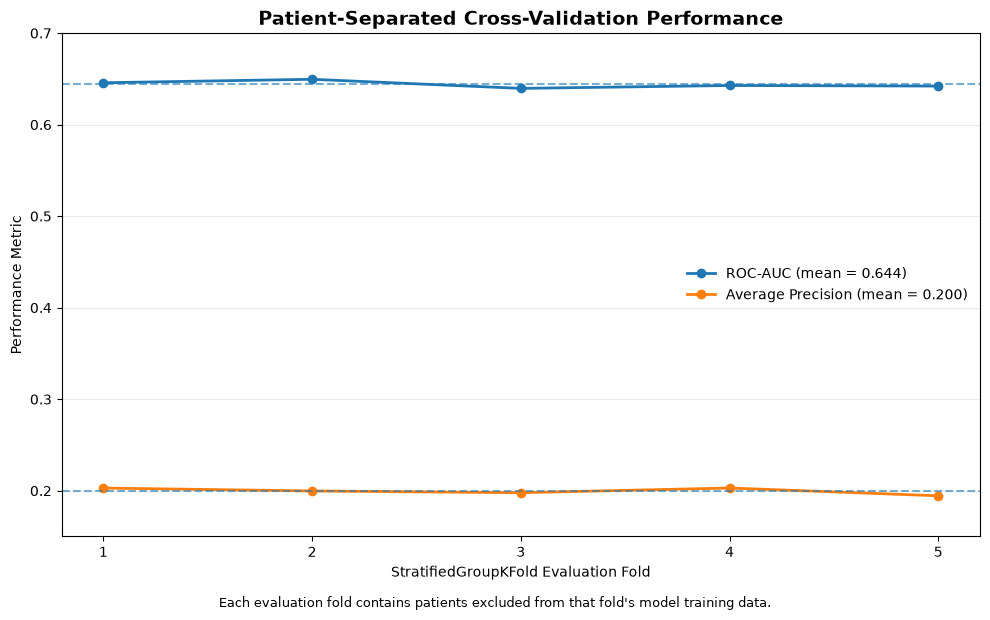


GROUP-AWARE CV FIGURE AUDIT
ROC-AUC mean: 0.6440
ROC-AUC range: 0.6396–0.6495
Average precision mean: 0.1996
Average precision range: 0.1945–0.2030
✓ Figure saved: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\figures\notebook07_cv_stability.png
✓ Five patient-separated folds represented.
✓ No model refitting or threshold selection performed.
✓ Held-out test partition untouched.


In [43]:
# M7S.1 — Group-aware cross-validation stability

import matplotlib.pyplot as plt

fold_plot_df = (
    cv_fold_results_df[
        [
            "fold",
            "roc_auc",
            "average_precision",
        ]
    ]
    .copy()
    .sort_values("fold")
)


mean_roc_auc = fold_plot_df["roc_auc"].mean()

mean_average_precision = fold_plot_df["average_precision"].mean()


fig, ax = plt.subplots(figsize=(10, 6))


ax.plot(
    fold_plot_df["fold"],
    fold_plot_df["roc_auc"],
    marker="o",
    linewidth=2,
    label=(f"ROC-AUC " f"(mean = {mean_roc_auc:.3f})"),
)

ax.plot(
    fold_plot_df["fold"],
    fold_plot_df["average_precision"],
    marker="o",
    linewidth=2,
    label=("Average Precision " f"(mean = {mean_average_precision:.3f})"),
)


ax.axhline(
    mean_roc_auc,
    linestyle="--",
    alpha=0.6,
)

ax.axhline(
    mean_average_precision,
    linestyle="--",
    alpha=0.6,
)


ax.set_title(
    "Patient-Separated Cross-Validation Performance",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("StratifiedGroupKFold Evaluation Fold")

ax.set_ylabel("Performance Metric")

ax.set_xticks(fold_plot_df["fold"])

ax.set_ylim(
    0.15,
    0.70,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend(
    frameon=False,
)


fig.text(
    0.5,
    -0.02,
    (
        "Each evaluation fold contains patients excluded "
        "from that fold's model training data."
    ),
    ha="center",
    fontsize=9,
)


plt.tight_layout()


# ----------------------------------------------------------
# Save portfolio/report figure
# ----------------------------------------------------------

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


cv_stability_figure_path = FIGURES_DIR / "notebook07_cv_stability.png"

fig.savefig(
    cv_stability_figure_path,
    dpi=300,
    bbox_inches="tight",
)


plt.show()


# ----------------------------------------------------------
# Figure integrity audit
# ----------------------------------------------------------

assert cv_stability_figure_path.exists()

assert cv_stability_figure_path.stat().st_size > 0

assert len(fold_plot_df) == 5

assert fold_plot_df["fold"].nunique() == 5


print("\nGROUP-AWARE CV FIGURE AUDIT")

print("=" * 70)

print(f"ROC-AUC mean: " f"{mean_roc_auc:.4f}")

print(
    "ROC-AUC range: "
    f"{fold_plot_df['roc_auc'].min():.4f}"
    "–"
    f"{fold_plot_df['roc_auc'].max():.4f}"
)

print("Average precision mean: " f"{mean_average_precision:.4f}")

print(
    "Average precision range: "
    f"{fold_plot_df['average_precision'].min():.4f}"
    "–"
    f"{fold_plot_df['average_precision'].max():.4f}"
)

print(f"✓ Figure saved: " f"{cv_stability_figure_path}")

print("✓ Five patient-separated folds represented.")

print("✓ No model refitting or threshold selection performed.")

print("✓ Held-out test partition untouched.")

### M7S.2 — Out-of-Fold Calibration Reliability

This reliability diagram compares mean predicted 30-day readmission probability with
the observed readmission rate across ten equal-frequency bins of genuine out-of-fold
predictions.

Perfect calibration would place each bin on the diagonal reference line. Points close
to that line indicate that predicted probabilities correspond reasonably well to
observed outcome frequencies.

This figure evaluates the original HGB probabilities before any post-hoc calibration.

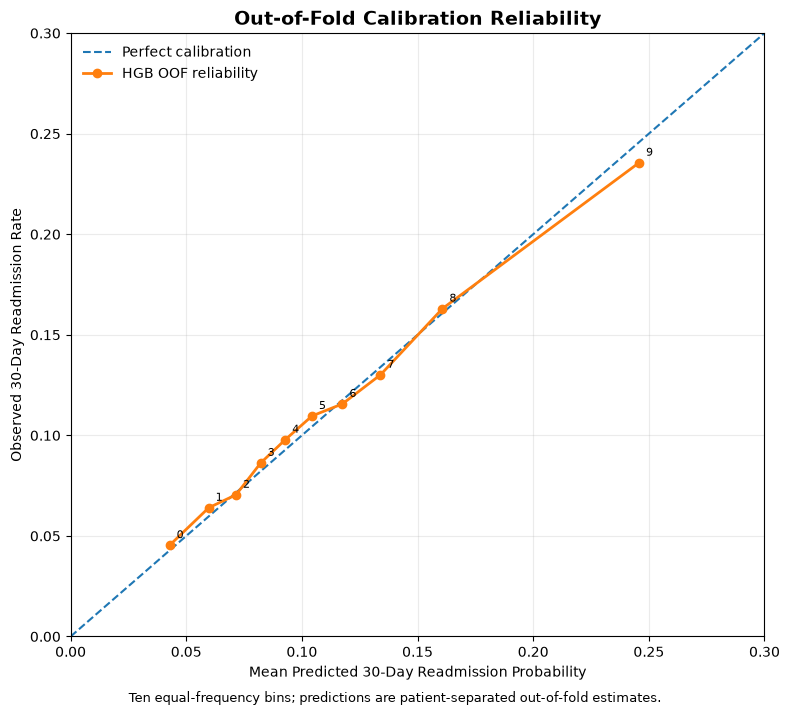


OOF CALIBRATION FIGURE AUDIT
Observed prevalence: 0.1118
Mean predicted probability: 0.1112
Expected calibration error: 0.0041
Calibration intercept: -0.1101
Calibration slope: 0.9409
✓ Figure saved: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\figures\notebook07_oof_calibration.png
✓ Ten equal-frequency OOF bins represented.
✓ Original HGB probabilities shown without post-hoc calibration.
✓ Held-out test partition untouched.


In [44]:
# M7S.2 — OOF calibration reliability diagram

calibration_plot_df = calibration_reliability_df.copy().sort_values(
    "predicted_probability"
)


fig, ax = plt.subplots(figsize=(8, 7))


# Perfect-calibration reference
calibration_limit = max(
    calibration_plot_df["predicted_probability"].max(),
    calibration_plot_df["observed_rate"].max(),
)

calibration_limit = max(
    0.30,
    calibration_limit * 1.05,
)


ax.plot(
    [0, calibration_limit],
    [0, calibration_limit],
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration",
)


# Observed reliability curve
ax.plot(
    calibration_plot_df["predicted_probability"],
    calibration_plot_df["observed_rate"],
    marker="o",
    linewidth=2,
    label="HGB OOF reliability",
)


# Annotate bins
for _, row in calibration_plot_df.iterrows():

    ax.annotate(
        str(int(row["calibration_bin"])),
        (
            row["predicted_probability"],
            row["observed_rate"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )


ax.set_xlim(
    0,
    calibration_limit,
)

ax.set_ylim(
    0,
    calibration_limit,
)


ax.set_title(
    "Out-of-Fold Calibration Reliability",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Mean Predicted 30-Day Readmission Probability")

ax.set_ylabel("Observed 30-Day Readmission Rate")

ax.grid(
    alpha=0.25,
)

ax.legend(
    frameon=False,
)


fig.text(
    0.5,
    -0.01,
    (
        "Ten equal-frequency bins; predictions are "
        "patient-separated out-of-fold estimates."
    ),
    ha="center",
    fontsize=9,
)


plt.tight_layout()


# ----------------------------------------------------------
# Save figure
# ----------------------------------------------------------

calibration_figure_path = FIGURES_DIR / "notebook07_oof_calibration.png"

fig.savefig(
    calibration_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------
# Figure integrity audit
# ----------------------------------------------------------

assert calibration_figure_path.exists()

assert calibration_figure_path.stat().st_size > 0

assert len(calibration_plot_df) == 10


print("\nOOF CALIBRATION FIGURE AUDIT")

print("=" * 70)

print(f"Observed prevalence: " f"{y_oof.mean():.4f}")

print(f"Mean predicted probability: " f"{oof_probability.mean():.4f}")

print(f"Expected calibration error: " f"{m7p_ece:.4f}")

print(f"Calibration intercept: " f"{calibration_intercept:.4f}")

print(f"Calibration slope: " f"{calibration_slope:.4f}")

print(f"✓ Figure saved: " f"{calibration_figure_path}")

print("✓ Ten equal-frequency OOF bins represented.")

print("✓ Original HGB probabilities shown without post-hoc calibration.")

print("✓ Held-out test partition untouched.")

### M7S.3 — Screening Threshold Trade-Off

The screening operating threshold determines the trade-off between identifying
30-day readmissions and the number of encounters flagged for follow-up.

This figure shows sensitivity, specificity, and the predicted-positive (screening)
rate across the development out-of-fold threshold grid. The locked threshold of
0.095 is shown as a fixed reference point.

The threshold was selected as a development-stage screening operating point rather
than as a clinically validated cutoff. No threshold optimization is performed in
this visualization.

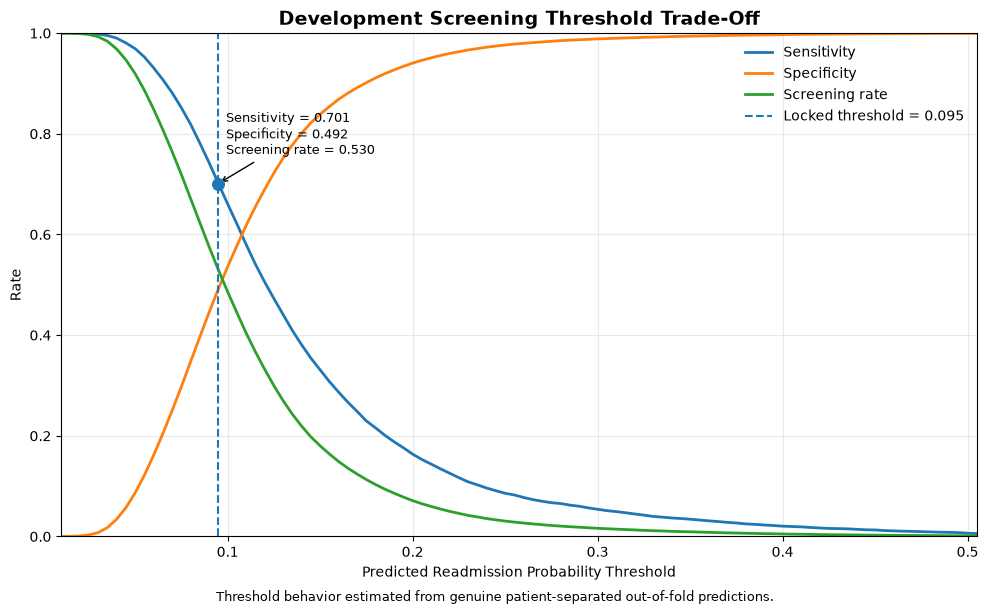


SCREENING THRESHOLD FIGURE AUDIT
Locked threshold: 0.095
Sensitivity: 0.7011
Specificity: 0.4921
Screening rate: 0.5295
✓ Figure saved: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\figures\notebook07_threshold_tradeoff.png
✓ Threshold curve uses genuine OOF predictions.
✓ Locked threshold shown without re-optimization.
✓ No subgroup-specific thresholding performed.
✓ Held-out test partition untouched.


In [45]:
# M7S.3 — Screening threshold trade-off

threshold_plot_df = oof_threshold_df.copy().sort_values("threshold")


fig, ax = plt.subplots(figsize=(10, 6))


ax.plot(
    threshold_plot_df["threshold"],
    threshold_plot_df["sensitivity"],
    linewidth=2,
    label="Sensitivity",
)

ax.plot(
    threshold_plot_df["threshold"],
    threshold_plot_df["specificity"],
    linewidth=2,
    label="Specificity",
)

ax.plot(
    threshold_plot_df["threshold"],
    threshold_plot_df["predicted_positive_rate"],
    linewidth=2,
    label="Screening rate",
)


# Locked development threshold
ax.axvline(
    LOCKED_HGB_SCREENING_THRESHOLD,
    linestyle="--",
    linewidth=1.5,
    label=("Locked threshold " f"= {LOCKED_HGB_SCREENING_THRESHOLD:.3f}"),
)


# Locked operating point
ax.scatter(
    [LOCKED_HGB_SCREENING_THRESHOLD],
    [locked_sensitivity],
    s=70,
    zorder=5,
)


ax.annotate(
    (
        f"Sensitivity = "
        f"{locked_sensitivity:.3f}\n"
        f"Specificity = "
        f"{locked_specificity:.3f}\n"
        f"Screening rate = "
        f"{locked_screening_rate:.3f}"
    ),
    xy=(
        LOCKED_HGB_SCREENING_THRESHOLD,
        locked_sensitivity,
    ),
    xytext=(
        0.18,
        0.76,
    ),
    textcoords="axes fraction",
    arrowprops={
        "arrowstyle": "->",
    },
    fontsize=9,
)


ax.set_title(
    "Development Screening Threshold Trade-Off",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Predicted Readmission Probability Threshold")

ax.set_ylabel("Rate")

ax.set_xlim(
    threshold_plot_df["threshold"].min(),
    threshold_plot_df["threshold"].max(),
)

ax.set_ylim(
    0,
    1,
)

ax.grid(
    alpha=0.25,
)

ax.legend(
    frameon=False,
)


fig.text(
    0.5,
    -0.01,
    (
        "Threshold behavior estimated from genuine "
        "patient-separated out-of-fold predictions."
    ),
    ha="center",
    fontsize=9,
)


plt.tight_layout()


# ----------------------------------------------------------
# Save figure
# ----------------------------------------------------------

threshold_figure_path = FIGURES_DIR / "notebook07_threshold_tradeoff.png"

fig.savefig(
    threshold_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------
# Figure integrity audit
# ----------------------------------------------------------

assert threshold_figure_path.exists()

assert threshold_figure_path.stat().st_size > 0

assert np.isclose(
    LOCKED_HGB_SCREENING_THRESHOLD,
    0.095,
)


print("\nSCREENING THRESHOLD FIGURE AUDIT")

print("=" * 70)

print(f"Locked threshold: " f"{LOCKED_HGB_SCREENING_THRESHOLD:.3f}")

print(f"Sensitivity: " f"{locked_sensitivity:.4f}")

print(f"Specificity: " f"{locked_specificity:.4f}")

print(f"Screening rate: " f"{locked_screening_rate:.4f}")

print(f"✓ Figure saved: " f"{threshold_figure_path}")

print("✓ Threshold curve uses genuine OOF predictions.")

print("✓ Locked threshold shown without re-optimization.")

print("✓ No subgroup-specific thresholding performed.")

print("✓ Held-out test partition untouched.")

### M7S.4 — Age-Group Robustness at the Locked Screening Threshold

Age showed the largest subgroup heterogeneity in the responsible-evaluation analysis.

This figure compares discrimination (ROC-AUC), sensitivity, and false-positive rate
across age groups using the same locked 0.095 screening threshold. Only groups meeting
the pre-specified subgroup sample requirements are shown.

The common threshold is retained for every age group; no subgroup-specific threshold
optimization is performed. Differences are descriptive and should not be interpreted
as evidence of causal discrimination.

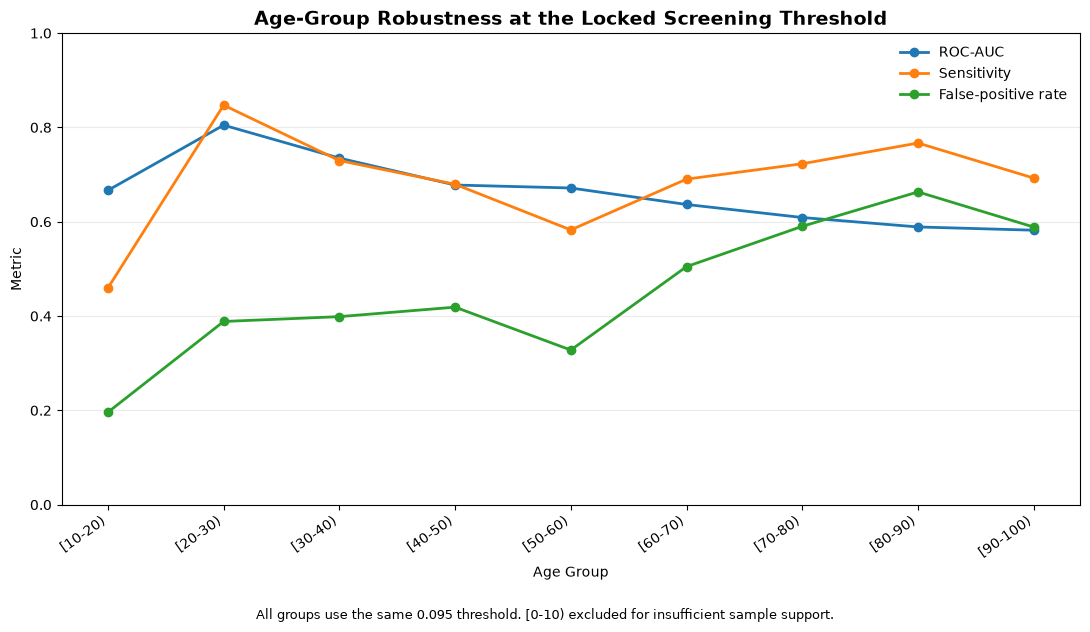


AGE ROBUSTNESS FIGURE AUDIT
Age groups represented: 9
Youngest represented group: [10-20)
Oldest represented group: [90-100)
Locked threshold: 0.095
✓ Figure saved: c:\Users\amohe.000\Downloads\healthcare-readmission-analytics\reports\figures\notebook07_age_robustness.png
✓ Only sufficient-sample groups represented.
✓ Same locked threshold used across age groups.
✓ No subgroup-specific threshold optimization.
✓ Differences remain descriptive rather than causal.
✓ Held-out test partition untouched.


In [46]:
# M7S.4 — Age-group robustness at the locked threshold

age_plot_df = age_subgroup_df.loc[age_subgroup_df["sufficient_sample"]].copy()


age_order = [
    "[10-20)",
    "[20-30)",
    "[30-40)",
    "[40-50)",
    "[50-60)",
    "[60-70)",
    "[70-80)",
    "[80-90)",
    "[90-100)",
]


age_plot_df["subgroup_value"] = pd.Categorical(
    age_plot_df["subgroup_value"],
    categories=age_order,
    ordered=True,
)


age_plot_df = age_plot_df.sort_values("subgroup_value")


fig, ax = plt.subplots(figsize=(11, 6))


ax.plot(
    age_plot_df["subgroup_value"],
    age_plot_df["roc_auc"],
    marker="o",
    linewidth=2,
    label="ROC-AUC",
)

ax.plot(
    age_plot_df["subgroup_value"],
    age_plot_df["sensitivity"],
    marker="o",
    linewidth=2,
    label="Sensitivity",
)

ax.plot(
    age_plot_df["subgroup_value"],
    age_plot_df["false_positive_rate"],
    marker="o",
    linewidth=2,
    label="False-positive rate",
)


ax.set_title(
    "Age-Group Robustness at the Locked Screening Threshold",
    fontsize=14,
    fontweight="bold",
)

ax.set_xlabel("Age Group")

ax.set_ylabel("Metric")

ax.set_ylim(
    0,
    1,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend(
    frameon=False,
)


plt.xticks(
    rotation=35,
    ha="right",
)


fig.text(
    0.5,
    -0.04,
    (
        "All groups use the same 0.095 threshold. "
        "[0-10) excluded for insufficient sample support."
    ),
    ha="center",
    fontsize=9,
)


plt.tight_layout()


# ----------------------------------------------------------
# Save figure
# ----------------------------------------------------------

age_robustness_figure_path = FIGURES_DIR / "notebook07_age_robustness.png"

fig.savefig(
    age_robustness_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# ----------------------------------------------------------
# Figure integrity audit
# ----------------------------------------------------------

assert age_robustness_figure_path.exists()

assert age_robustness_figure_path.stat().st_size > 0

assert age_plot_df["subgroup_value"].nunique() == 9

assert "[0-10)" not in age_plot_df["subgroup_value"].astype(str).tolist()


print("\nAGE ROBUSTNESS FIGURE AUDIT")

print("=" * 70)

print(
    "Age groups represented:",
    age_plot_df["subgroup_value"].nunique(),
)

print(
    "Youngest represented group:",
    age_plot_df["subgroup_value"].iloc[0],
)

print(
    "Oldest represented group:",
    age_plot_df["subgroup_value"].iloc[-1],
)

print(f"Locked threshold: " f"{LOCKED_HGB_SCREENING_THRESHOLD:.3f}")

print(f"✓ Figure saved: " f"{age_robustness_figure_path}")

print("✓ Only sufficient-sample groups represented.")

print("✓ Same locked threshold used across age groups.")

print("✓ No subgroup-specific threshold optimization.")

print("✓ Differences remain descriptive rather than causal.")

print("✓ Held-out test partition untouched.")

In [47]:
# M7S.5 — Visualization artifact integrity audit

visualization_artifacts = {
    "CV stability": cv_stability_figure_path,
    "OOF calibration": calibration_figure_path,
    "Threshold trade-off": threshold_figure_path,
    "Age robustness": age_robustness_figure_path,
}


print("NOTEBOOK 07 VISUALIZATION ARTIFACT AUDIT")

print("=" * 90)


for label, path in visualization_artifacts.items():

    assert path.exists(), f"Missing figure: {path}"

    assert path.stat().st_size > 0, f"Empty figure: {path}"

    print(f"✓ {label:<25} " f"{path.name:<40} " f"{path.stat().st_size:>10,} bytes")


print(
    "\nFigures saved:",
    len(visualization_artifacts),
)

print("✓ Four validation figures persisted at 300 DPI.")

print("✓ Figures use development OOF/validation results only.")

print("✓ No additional model selection performed.")

print("✓ Held-out test partition remains untouched.")

NOTEBOOK 07 VISUALIZATION ARTIFACT AUDIT
✓ CV stability              notebook07_cv_stability.png                 137,378 bytes
✓ OOF calibration           notebook07_oof_calibration.png              200,313 bytes
✓ Threshold trade-off       notebook07_threshold_tradeoff.png           261,728 bytes
✓ Age robustness            notebook07_age_robustness.png               251,549 bytes

Figures saved: 4
✓ Four validation figures persisted at 300 DPI.
✓ Figures use development OOF/validation results only.
✓ No additional model selection performed.
✓ Held-out test partition remains untouched.


## M7T — Reproducibility and Final Integrity Check

Notebook 07 is considered complete only after a clean-kernel execution succeeds from
top to bottom.

Final integrity requirements:

- all development data are loaded explicitly,
- no variables depend on hidden notebook state,
- fold-local preprocessing is reconstructed within each fold,
- the locked HGB configuration remains unchanged,
- out-of-fold predictions cover every development encounter exactly once,
- patient groups remain separated across folds,
- calibration, threshold, bootstrap, and subgroup analyses reproduce,
- validation artifacts are regenerated successfully,
- no held-out HGB test evaluation occurs in this notebook.

After restarting the kernel, the notebook should execute successfully using **Run All**
without manual intervention.